#TECH CHALLENGE - POS TECH
Fase05 - Datathon – Passos Mágicos
Rodrigo Santiago Silva - rm369341 - Turma 12DTAT

Este notebook apresenta o desenvolvimento de um modelo de Machine Learning para identificar alunos com risco de defasagem educacional.

A partir dos indicadores disponíveis na base, serão realizadas as etapas de preparação dos dados, engenharia de atributos, divisão entre treino e teste, treinamento do modelo e avaliação dos resultados.

O objetivo é identificar padrões de risco antecipadamente, contribuindo para que a Associação Passos Mágicos possa direcionar ações de acompanhamento e intervenção.

In [ ]:
import numpy as np
import pandas as pd

# Substitua 'seu_arquivo.xlsx' pelo nome do arquivo enviado ao Colab
nome_arquivo = 'BASE DE DADOS PEDE 2024 - DATATHON.xlsx'  # Ou use o nome exato da sua planilha

# 1. Carregar o arquivo Excel e listar os nomes de todas as abas
excel_file = pd.ExcelFile(nome_arquivo)
print("📌 Abas encontradas na planilha:", excel_file.sheet_names)

# Dictionary para armazenar os DataFrames de cada ano
dfs = {}

# 2. Ler cada aba e exibir a estrutura de colunas
for aba in excel_file.sheet_names:
    dfs[aba] = pd.read_excel(excel_file, sheet_name=aba)
    df_temp = dfs[aba]

    print(f"\n==================================================")
    print(f"📊 ABA / ANO: {aba}")
    print(f"Dimensões: {df_temp.shape[0]} linhas x {df_temp.shape[1]} colunas")
    print(f"==================================================")

    # Criar um resumo detalhado de todas as colunas
    resumo_colunas = pd.DataFrame({
        'Coluna': df_temp.columns,
        'Tipo': df_temp.dtypes.values,
        'Nulos': df_temp.isnull().sum().values,
        'Nulos (%)': (df_temp.isnull().sum().values / len(df_temp) * 100).round(1),
        'Exemplo': [df_temp[col].dropna().iloc[0] if not df_temp[col].dropna().empty else None for col in df_temp.columns]
    })

    # Exibir a tabela completa de colunas sem cortar nenhuma linha
    pd.set_option('display.max_rows', None)
    display(resumo_colunas)

📌 Abas encontradas na planilha: ['PEDE2022', 'PEDE2023', 'PEDE2024']

📊 ABA / ANO: PEDE2022
Dimensões: 860 linhas x 42 colunas


,Coluna,Tipo,Nulos,Nulos (%),Exemplo
0,RA,object,0,0.0,RA-1
1,Fase,int64,0,0.0,7
2,Turma,object,0,0.0,A
3,Nome,object,0,0.0,Aluno-1
4,Ano nasc,int64,0,0.0,2003
5,Idade 22,int64,0,0.0,19
6,Gênero,object,0,0.0,Menina
7,Ano ingresso,int64,0,0.0,2016
8,Instituição de ensino,object,0,0.0,Escola Pública
9,Pedra 20,object,537,62.4,Ametista



📊 ABA / ANO: PEDE2023
Dimensões: 1014 linhas x 48 colunas


,Coluna,Tipo,Nulos,Nulos (%),Exemplo
0,RA,object,0,0.0,RA-861
1,Fase,object,0,0.0,ALFA
2,INDE 2023,float64,83,8.2,9.31095
3,Pedra 2023,object,83,8.2,Topázio
4,Turma,object,0,0.0,ALFA A - G0/G1
5,Nome Anonimizado,object,0,0.0,Aluno-861
6,Data de Nasc,object,0,0.0,6/17/2015
7,Idade,object,0,0.0,8
8,Gênero,object,0,0.0,Feminino
9,Ano ingresso,int64,0,0.0,2023



📊 ABA / ANO: PEDE2024
Dimensões: 1156 linhas x 50 colunas


,Coluna,Tipo,Nulos,Nulos (%),Exemplo
0,RA,object,0,0.0,RA-1275
1,Fase,object,0,0.0,ALFA
2,INDE 2024,object,64,5.5,7.611367
3,Pedra 2024,object,64,5.5,Ametista
4,Turma,object,0,0.0,ALFA A - G0/G1
5,Nome Anonimizado,object,0,0.0,Aluno-1275
6,Data de Nasc,datetime64[ns],0,0.0,2016-07-28 00:00:00
7,Idade,int64,0,0.0,8
8,Gênero,object,0,0.0,Masculino
9,Ano ingresso,int64,0,0.0,2024


In [ ]:
# Criar uma lista de colunas para cada aba
colunas_por_aba = {aba: list(dfs[aba].columns) for aba in excel_file.sheet_names}

# Identificar o tamanho máximo para alinhar em um DataFrame
max_len = max(len(cols) for cols in colunas_por_aba.values())

# Preencher abas com menos colunas com None para alinhar
colunas_alinhadas = {
    aba: cols + [None] * (max_len - len(cols))
    for aba, cols in colunas_por_aba.items()
}

df_colunas_comparativo = pd.DataFrame(colunas_alinhadas)
print("\n📌 Comparativo visual de colunas por aba:")
display(df_colunas_comparativo)


📌 Comparativo visual de colunas por aba:


,PEDE2022,PEDE2023,PEDE2024
0,RA,RA,RA
1,Fase,Fase,Fase
2,Turma,INDE 2023,INDE 2024
3,Nome,Pedra 2023,Pedra 2024
4,Ano nasc,Turma,Turma
5,Idade 22,Nome Anonimizado,Nome Anonimizado
6,Gênero,Data de Nasc,Data de Nasc
7,Ano ingresso,Idade,Idade
8,Instituição de ensino,Gênero,Gênero
9,Pedra 20,Ano ingresso,Ano ingresso


In [ ]:
excel_file = pd.ExcelFile(nome_arquivo)

print("=" * 60)
print("LISTA DE COLUNAS POR ABA / ANO")
print("=" * 60)

for aba in excel_file.sheet_names:
    df_temp = pd.read_excel(excel_file, sheet_name=aba)
    print(f"\n--- ABA: {aba} (Total de colunas: {len(df_temp.columns)}) ---")
    for i, col in enumerate(df_temp.columns, start=1):
        print(f"{i}. {col}")

print("\n" + "=" * 60)

LISTA DE COLUNAS POR ABA / ANO

--- ABA: PEDE2022 (Total de colunas: 42) ---
1. RA
2. Fase
3. Turma
4. Nome
5. Ano nasc
6. Idade 22
7. Gênero
8. Ano ingresso
9. Instituição de ensino
10. Pedra 20
11. Pedra 21
12. Pedra 22
13. INDE 22
14. Cg
15. Cf
16. Ct
17. Nº Av
18. Avaliador1
19. Rec Av1
20. Avaliador2
21. Rec Av2
22. Avaliador3
23. Rec Av3
24. Avaliador4
25. Rec Av4
26. IAA
27. IEG
28. IPS
29. Rec Psicologia
30. IDA
31. Matem
32. Portug
33. Inglês
34. Indicado
35. Atingiu PV
36. IPV
37. IAN
38. Fase ideal
39. Defas
40. Destaque IEG
41. Destaque IDA
42. Destaque IPV

--- ABA: PEDE2023 (Total de colunas: 48) ---
1. RA
2. Fase
3. INDE 2023
4. Pedra 2023
5. Turma
6. Nome Anonimizado
7. Data de Nasc
8. Idade
9. Gênero
10. Ano ingresso
11. Instituição de ensino
12. Pedra 20
13. Pedra 21
14. Pedra 22
15. Pedra 23
16. INDE 22
17. INDE 23
18. Cg
19. Cf
20. Ct
21. Nº Av
22. Avaliador1
23. Rec Av1
24. Avaliador2
25. Rec Av2
26. Avaliador3
27. Rec Av3
28. Avaliador4
29. Rec Av4
30. IAA
31. IEG

In [ ]:
# Dicionários de renomeação para padronizar os nomes entre os 3 anos
renomear_2022 = {
    'Nome': 'Nome',
    'Idade 22': 'Idade',
    'Matem': 'Mat',
    'Portug': 'Por',
    'Inglês': 'Ing',
    'Defas': 'Defasagem',
    'Fase ideal': 'Fase_Ideal',
    'Pedra 22': 'Pedra',
    'INDE 22': 'INDE'
}

renomear_2023 = {
    'Nome Anonimizado': 'Nome',
    'Fase Ideal': 'Fase_Ideal',
    'Pedra 2023': 'Pedra',
    'INDE 2023': 'INDE'
}

renomear_2024 = {
    'Nome Anonimizado': 'Nome',
    'Fase Ideal': 'Fase_Ideal',
    'Pedra 2024': 'Pedra',
    'INDE 2024': 'INDE',
    'Escola': 'Instituição de ensino'
}

# Colunas principais que queremos manter na base final unificada
colunas_alvo = [
    'RA', 'Nome', 'Ano_Exercicio', 'Fase', 'Turma', 'Gênero', 'Idade', 'Ano ingresso',
    'Instituição de ensino', 'Pedra', 'INDE', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA',
    'IPV', 'IAN', 'Mat', 'Por', 'Ing', 'Fase_Ideal', 'Defasagem', 'Atingiu PV',
    'Indicado', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'Rec Psicologia'
]

dfs_processados = []

for aba in excel_file.sheet_names:
    df_temp = pd.read_excel(excel_file, sheet_name=aba)

    # 1. Limpar espaços nos nomes das colunas
    df_temp.columns = df_temp.columns.astype(str).str.strip()

    # 2. Remover colunas com nomes duplicados no dataframe original da aba
    df_temp = df_temp.loc[:, ~df_temp.columns.duplicated(keep='first')].copy()

    # 3. Mapear e adicionar a coluna de Ano do Exercício
    if '2022' in aba:
        df_temp = df_temp.rename(columns=renomear_2022)
        df_temp['Ano_Exercicio'] = 2022
    elif '2023' in aba:
        df_temp = df_temp.rename(columns=renomear_2023)
        df_temp['Ano_Exercicio'] = 2023
    elif '2024' in aba:
        df_temp = df_temp.rename(columns=renomear_2024)
        df_temp['Ano_Exercicio'] = 2024

    # 4. Garantir novamente remoção de duplicatas após a renomeação
    df_temp = df_temp.loc[:, ~df_temp.columns.duplicated(keep='first')].copy()

    # 5. Garantir que todas as colunas da lista alvo existam no DataFrame
    for col in colunas_alvo:
        if col not in df_temp.columns:
            df_temp[col] = np.nan

    # 6. Filtrar e reordenar estritamente segundo a lista colunas_alvo
    df_filtrado = df_temp[colunas_alvo].copy()
    dfs_processados.append(df_filtrado)

# 7. Unificar as 3 bases no formato Tidy
df_passos = pd.concat(dfs_processados, ignore_index=True)

print("✅ Base Unificada Criada com Sucesso!")
print(f"Dimensões finais: {df_passos.shape[0]} linhas x {df_passos.shape[1]} colunas\n")
display(df_passos.head())

✅ Base Unificada Criada com Sucesso!
Dimensões finais: 3030 linhas x 29 colunas



,RA,Nome,Ano_Exercicio,Fase,Turma,Gênero,Idade,Ano ingresso,Instituição de ensino,Pedra,...,Por,Ing,Fase_Ideal,Defasagem,Atingiu PV,Indicado,Destaque IEG,Destaque IDA,Destaque IPV,Rec Psicologia
0,RA-1,Aluno-1,2022,7,A,Menina,19,2016,Escola Pública,Quartzo,...,3.5,6.0,Fase 8 (Universitários),-1,Não,Sim,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,Requer avaliação
1,RA-2,Aluno-2,2022,7,A,Menina,17,2017,Rede Decisão,Ametista,...,4.5,9.7,Fase 7 (3º EM),0,Não,Não,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,Sem limitações
2,RA-3,Aluno-3,2022,7,A,Menina,17,2016,Rede Decisão,Ágata,...,4.0,6.9,Fase 7 (3º EM),0,Não,Não,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,Sem limitações
3,RA-4,Aluno-4,2022,7,A,Menino,17,2017,Rede Decisão,Quartzo,...,3.5,8.7,Fase 7 (3º EM),0,Não,Não,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,Requer avaliação
4,RA-5,Aluno-5,2022,7,A,Menina,17,2016,Rede Decisão,Ametista,...,2.9,5.7,Fase 7 (3º EM),0,Não,Não,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,Requer avaliação


In [ ]:
# 1. Contagem de Alunos Únicos por RA
total_registros = len(df_passos)
alunos_unicos = df_passos['RA'].nunique()

print(f"📌 Total de registros na base: {total_registros}")
print(f"📌 Total de alunos únicos (RAs distintos): {alunos_unicos}\n")

# 2. Distribuição de alunos por quantidade de anos de participação
anos_por_aluno = df_passos.groupby('RA')['Ano_Exercicio'].nunique().value_counts().sort_index()

print("📊 Quantidade de anos em que os alunos aparecem na base:")
for anos, qtd in anos_por_aluno.items():
    print(f"  - Aparecem em {anos} ano(s): {qtd} alunos")

print("\n" + "="*60)
print("🔍 EXEMPLO DE RASTREAMENTO LONGITUDINAL (Exemplo de 1 Aluno):")
print("="*60)

# 3. Exemplo visual da jornada de um aluno que esteve presente em múltiplos anos
ra_exemplo = df_passos.groupby('RA')['Ano_Exercicio'].count().sort_values(ascending=False).index[0]
df_aluno_exemplo = df_passos[df_passos['RA'] == ra_exemplo][['RA', 'Nome', 'Ano_Exercicio', 'Fase', 'Pedra', 'INDE', 'IDA', 'IEG', 'IAN']].sort_values('Ano_Exercicio')

display(df_aluno_exemplo)

📌 Total de registros na base: 3030
📌 Total de alunos únicos (RAs distintos): 1661

📊 Quantidade de anos em que os alunos aparecem na base:
  - Aparecem em 1 ano(s): 760 alunos
  - Aparecem em 2 ano(s): 433 alunos
  - Aparecem em 3 ano(s): 468 alunos

🔍 EXEMPLO DE RASTREAMENTO LONGITUDINAL (Exemplo de 1 Aluno):


,RA,Nome,Ano_Exercicio,Fase,Pedra,INDE,IDA,IEG,IAN
95,RA-96,Aluno-96,2022,5,Ametista,7.54,6.7,7.8,5.0
1780,RA-96,Aluno-96,2023,FASE 6,Ametista,7.610792,6.4,8.9,5.0
2983,RA-96,Aluno-96,2024,8F,NaN,NaN,NaN,0.0,10.0


In [ ]:
!pip install missingno

📊 Gerando gráficos de nulidade: ANTES DA LIMPEZA E IMPUTAÇÃO...


<Figure size 1200x600 with 0 Axes>

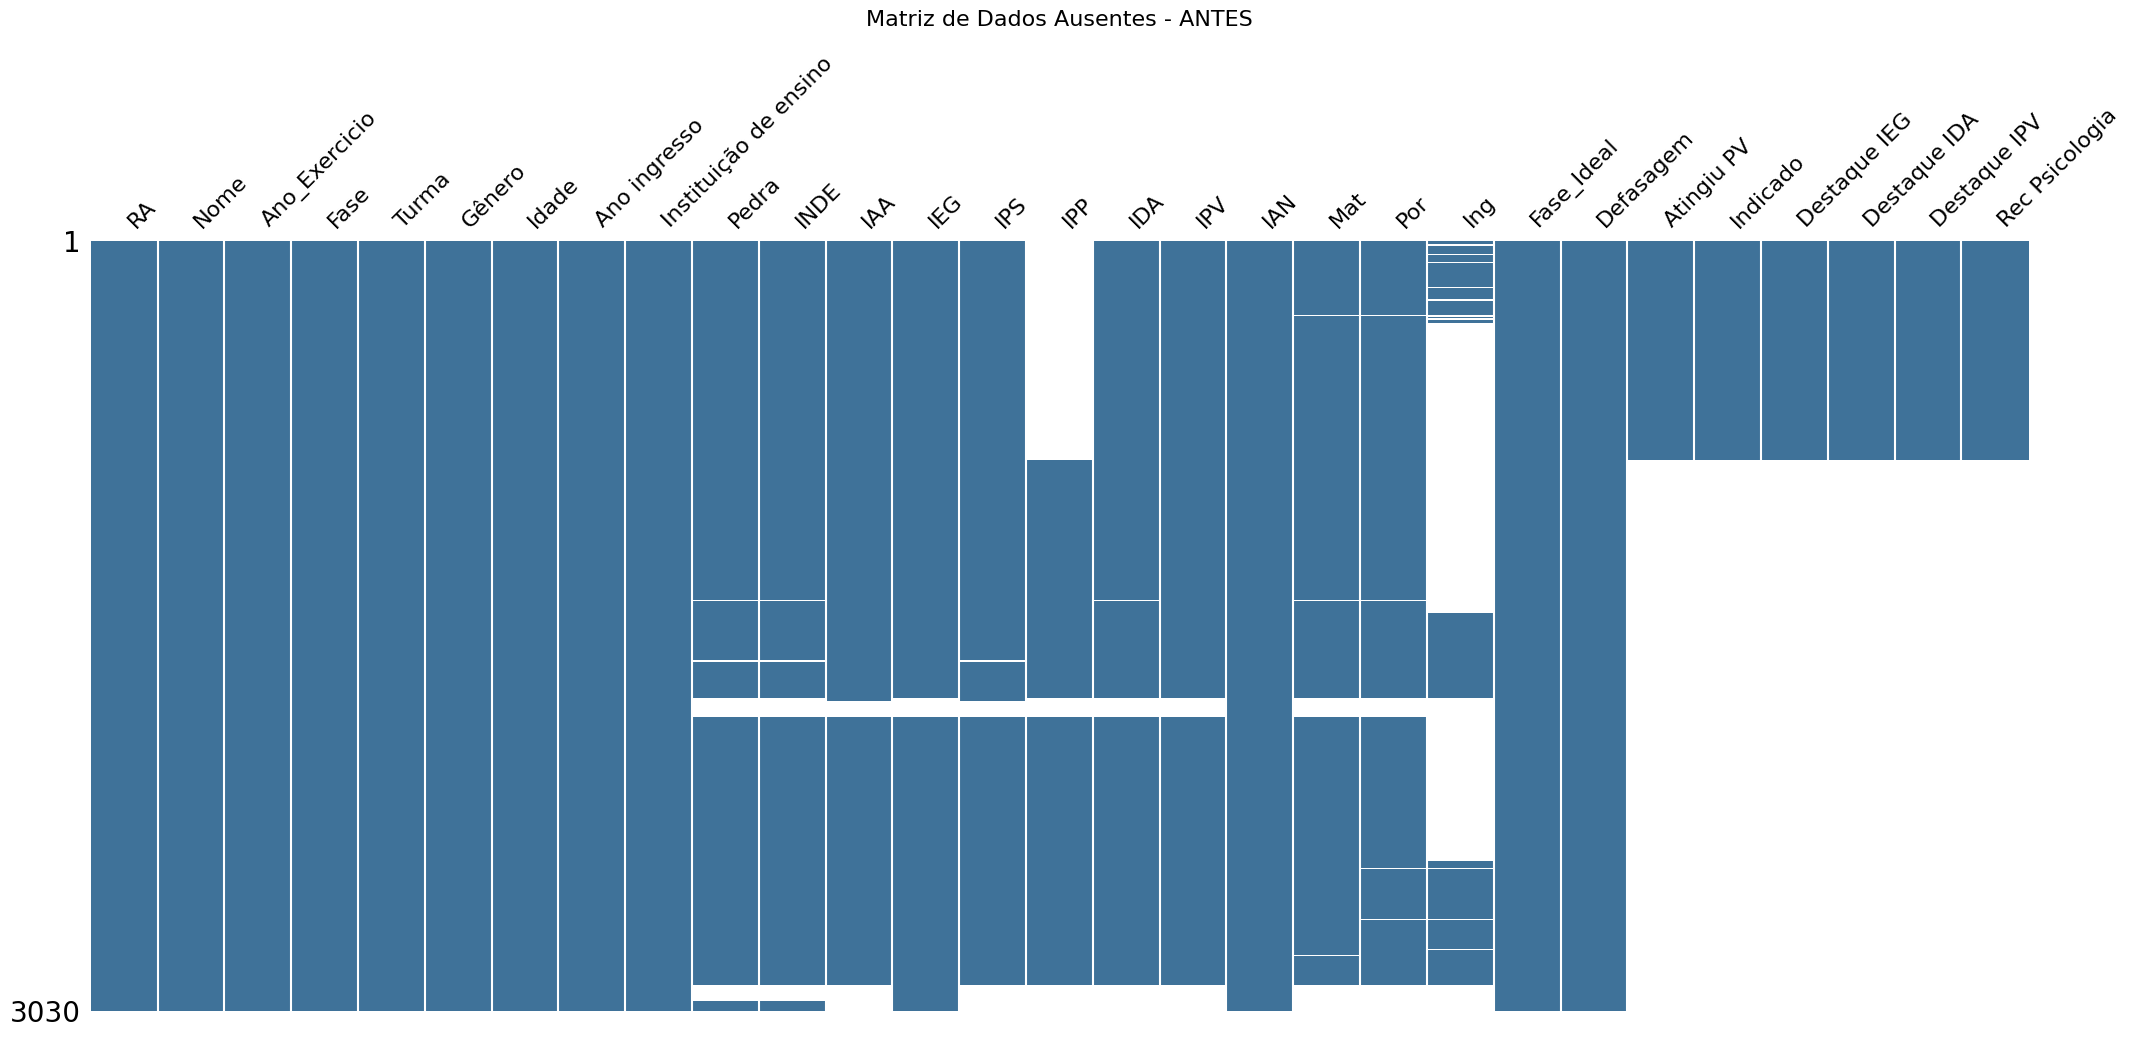

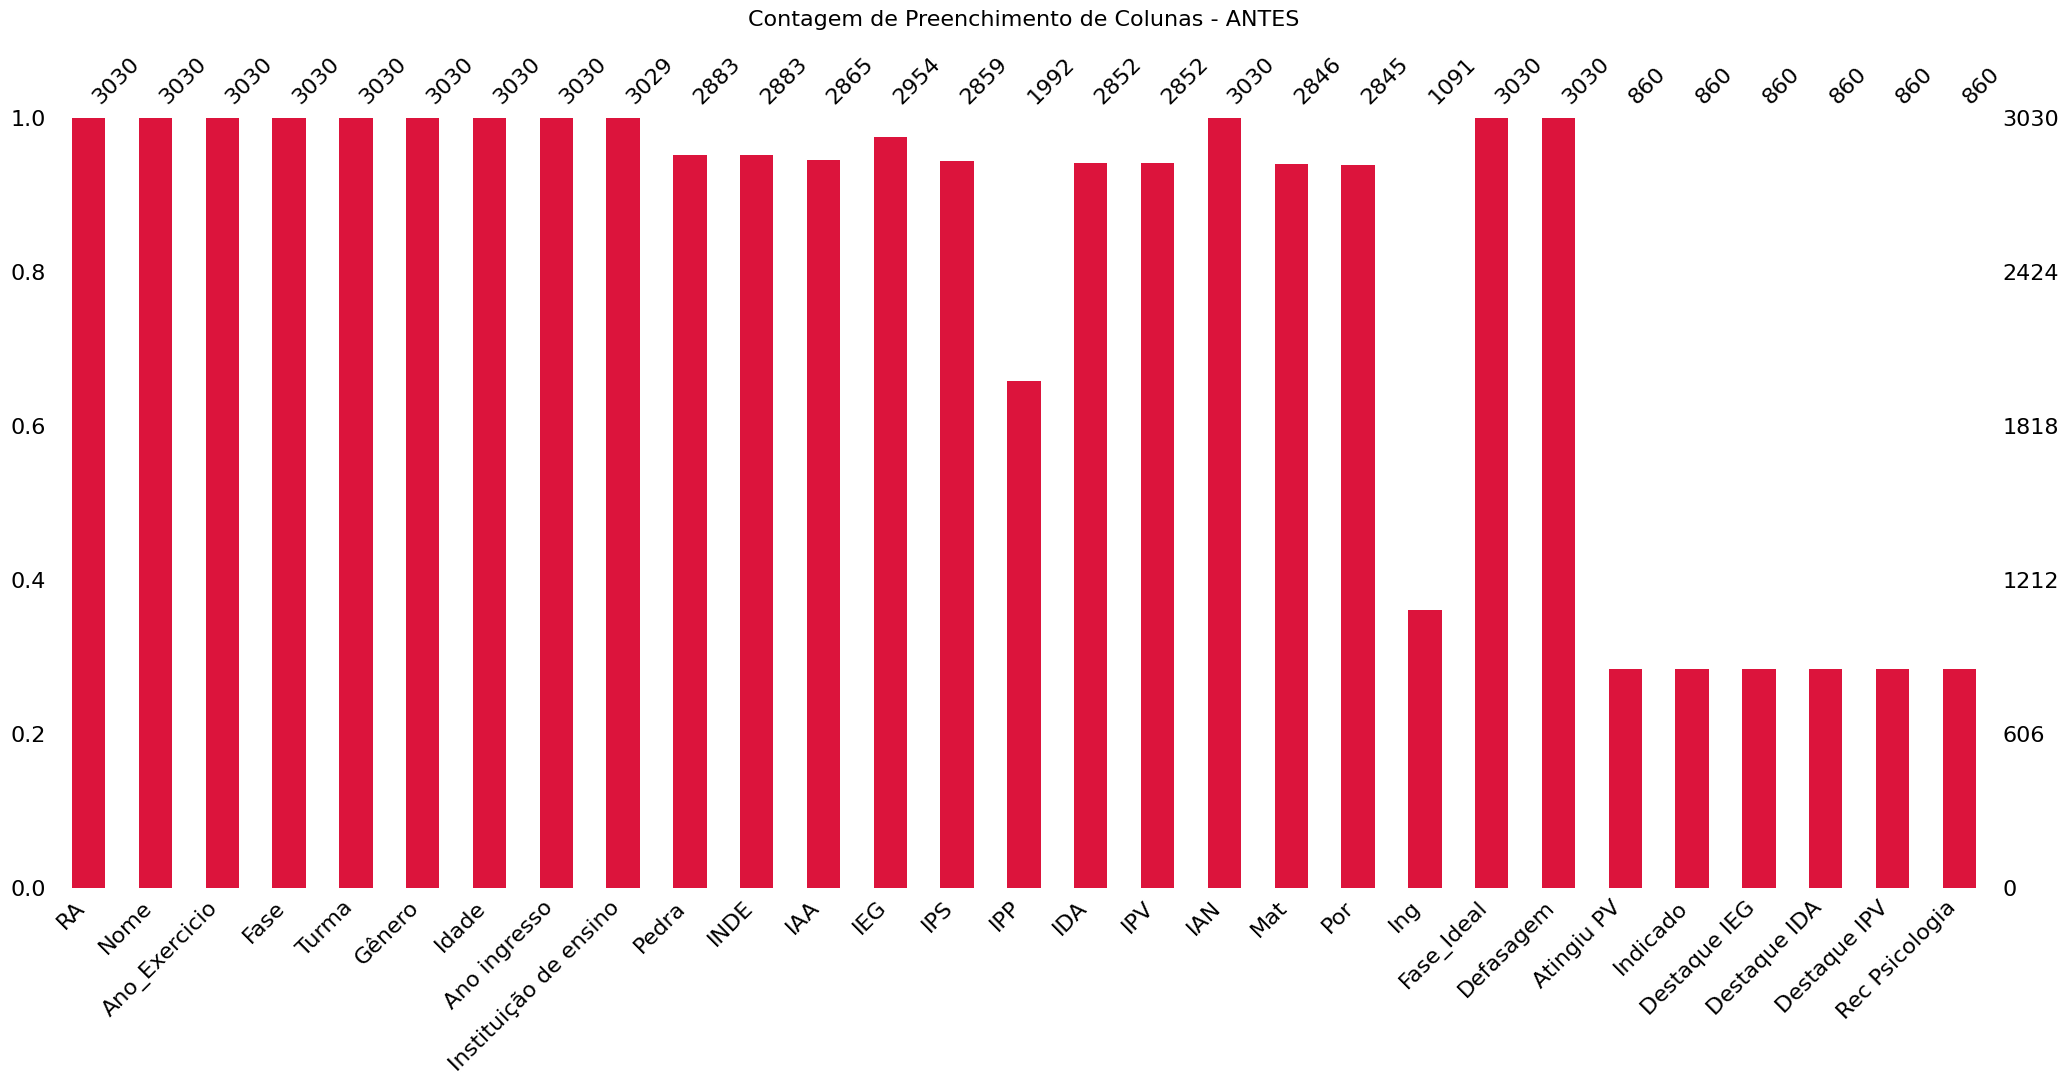

<Figure size 1200x600 with 0 Axes>

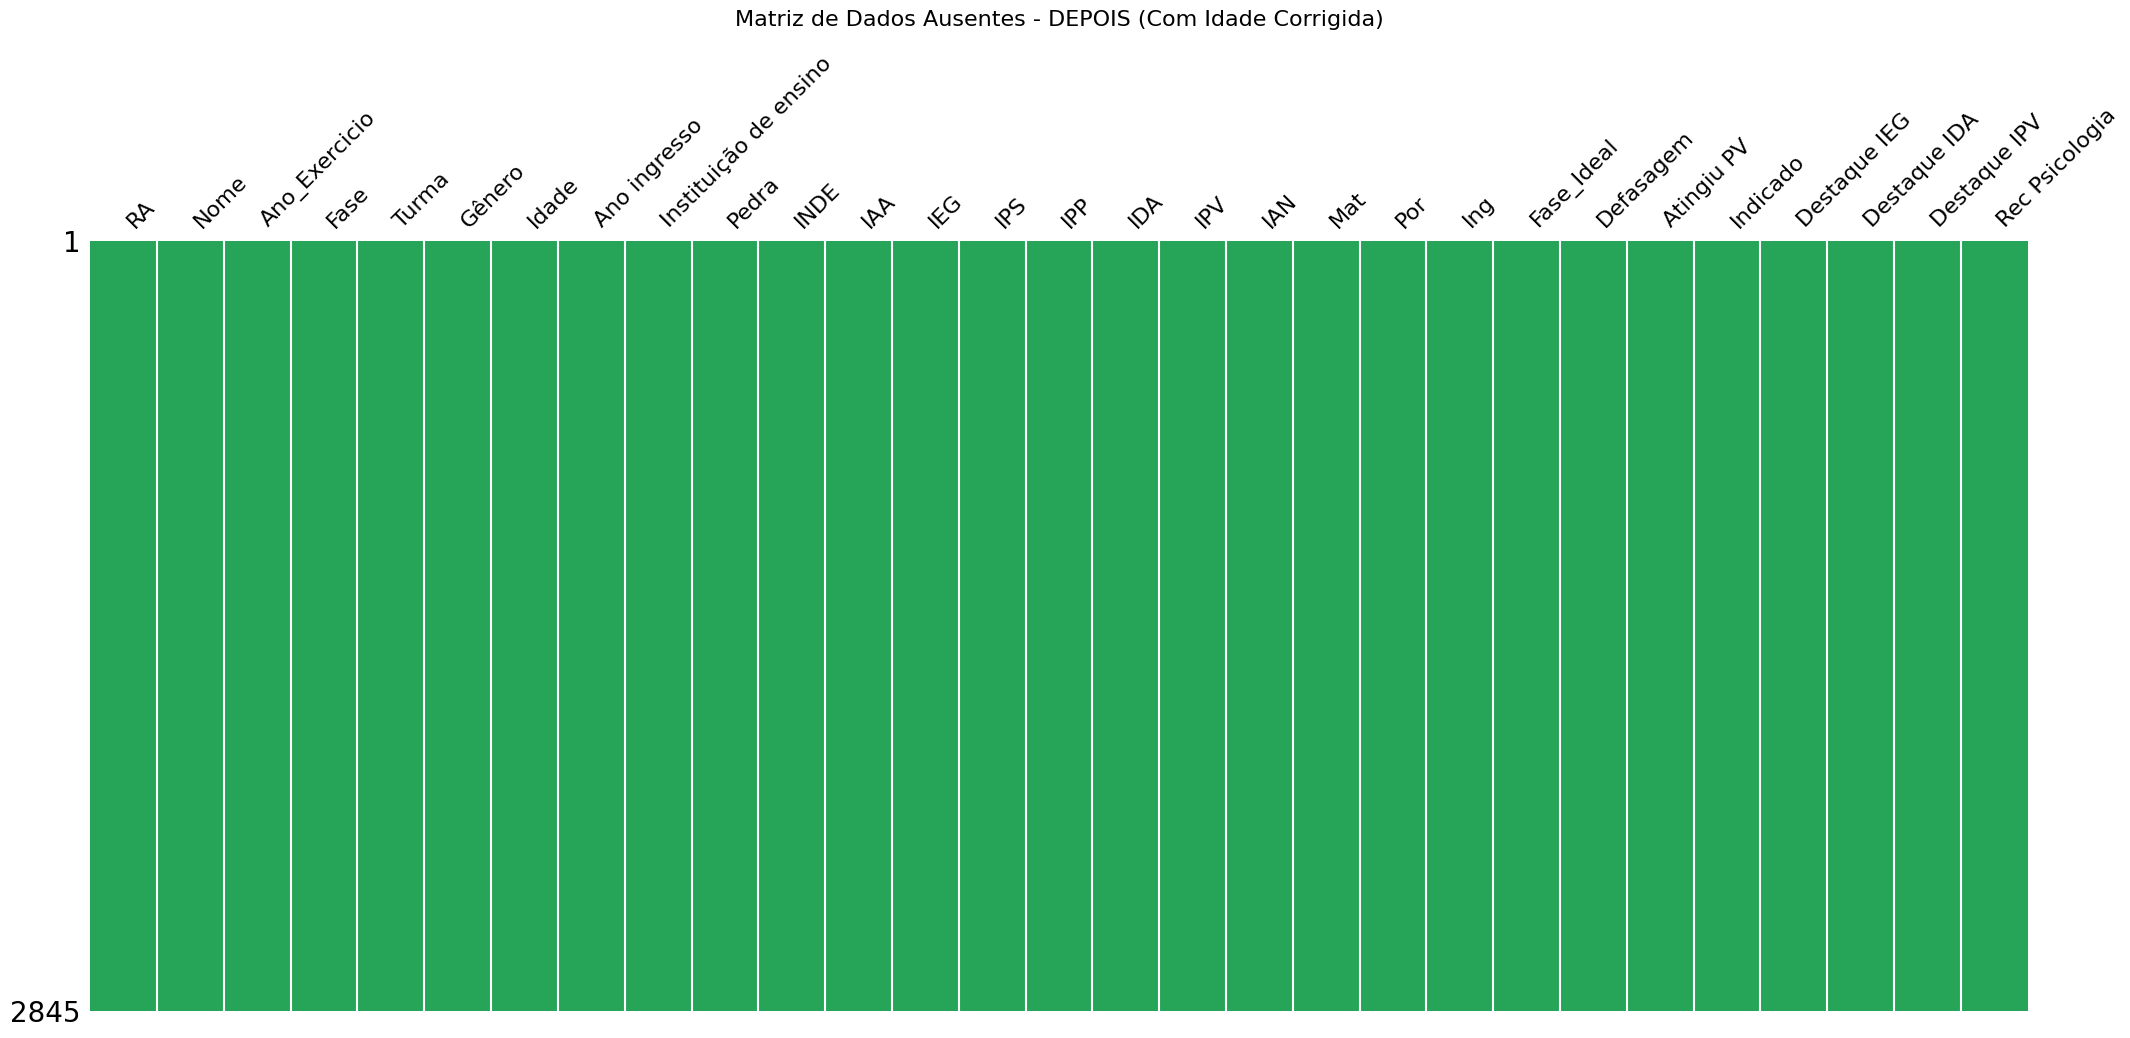


✅ Gerando gráficos de nulidade: DEPOIS DA LIMPEZA E IMPUTAÇÃO...


<Figure size 1200x600 with 0 Axes>

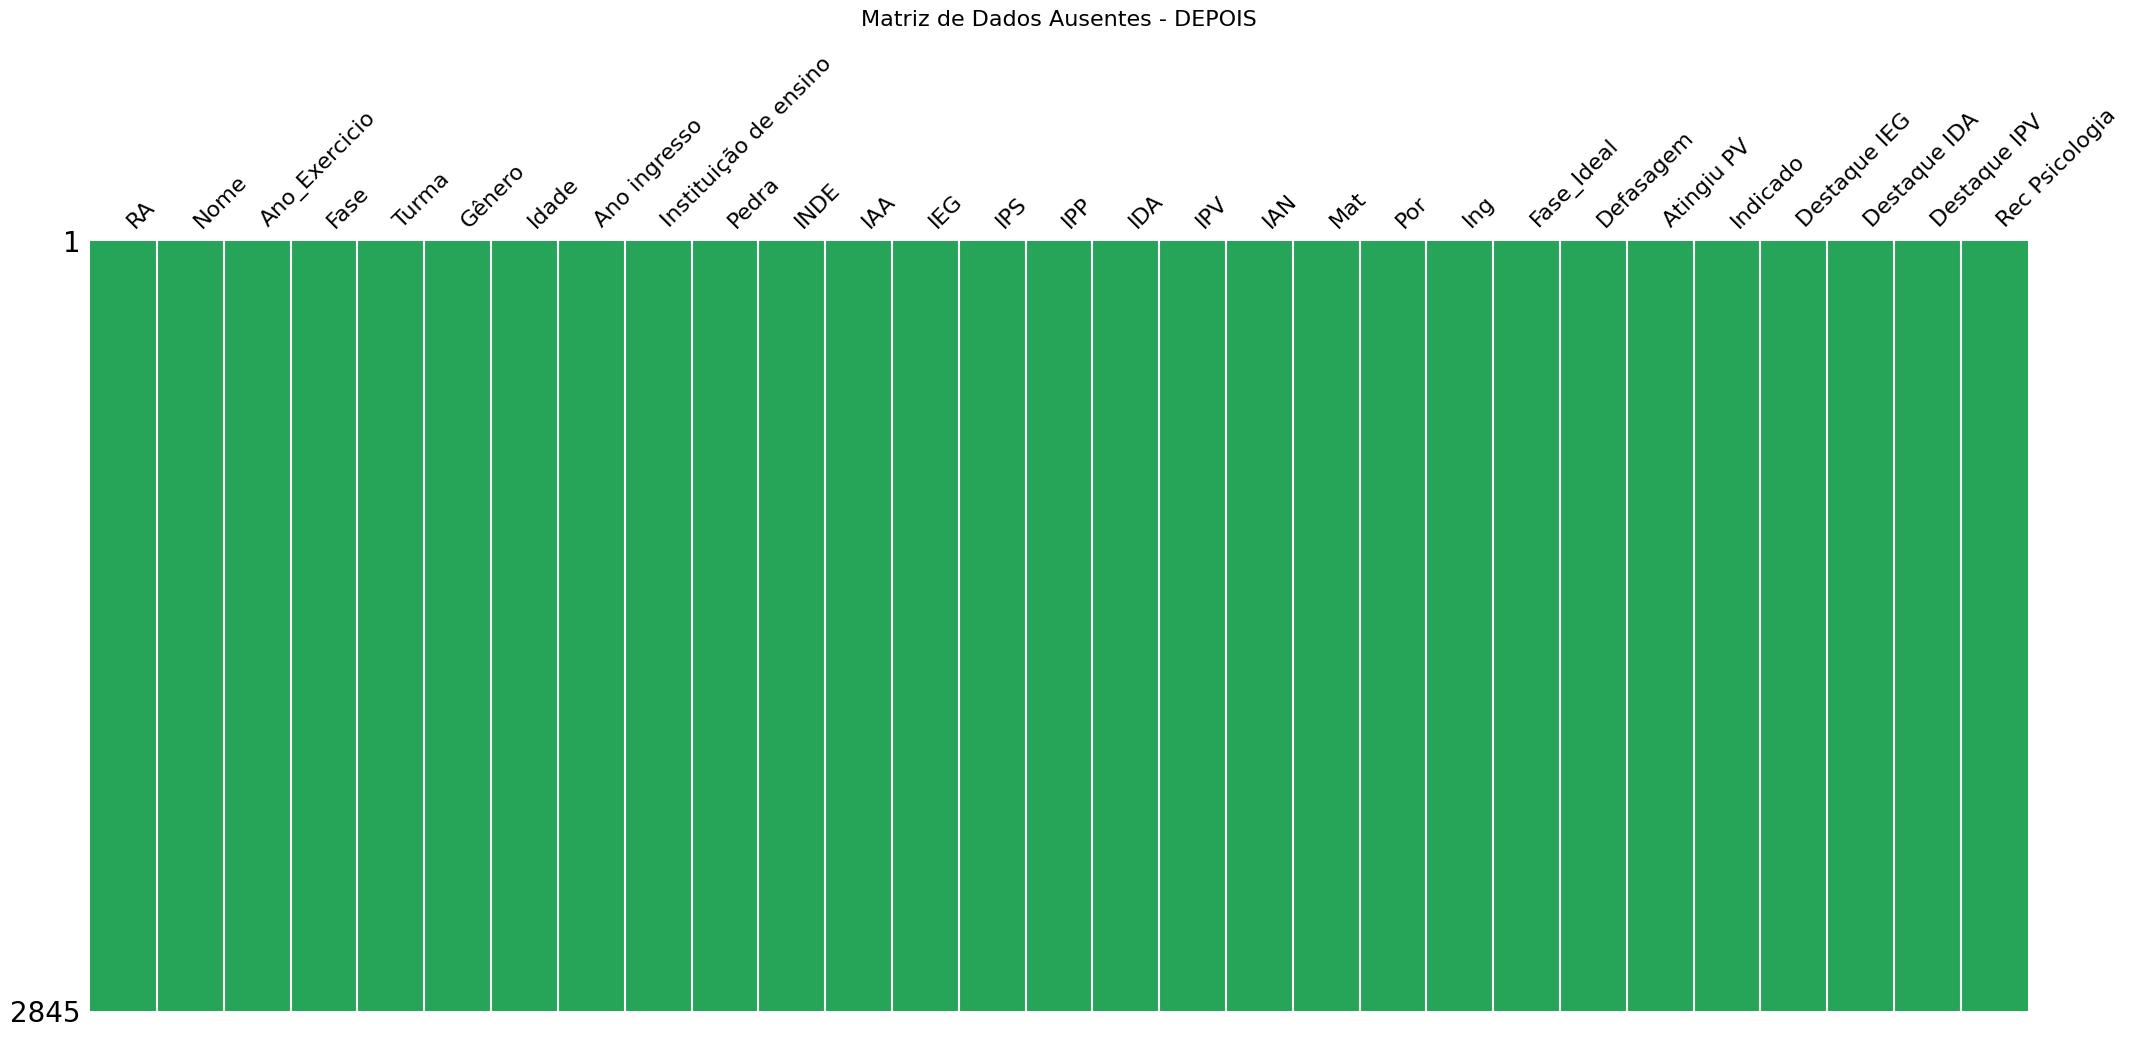

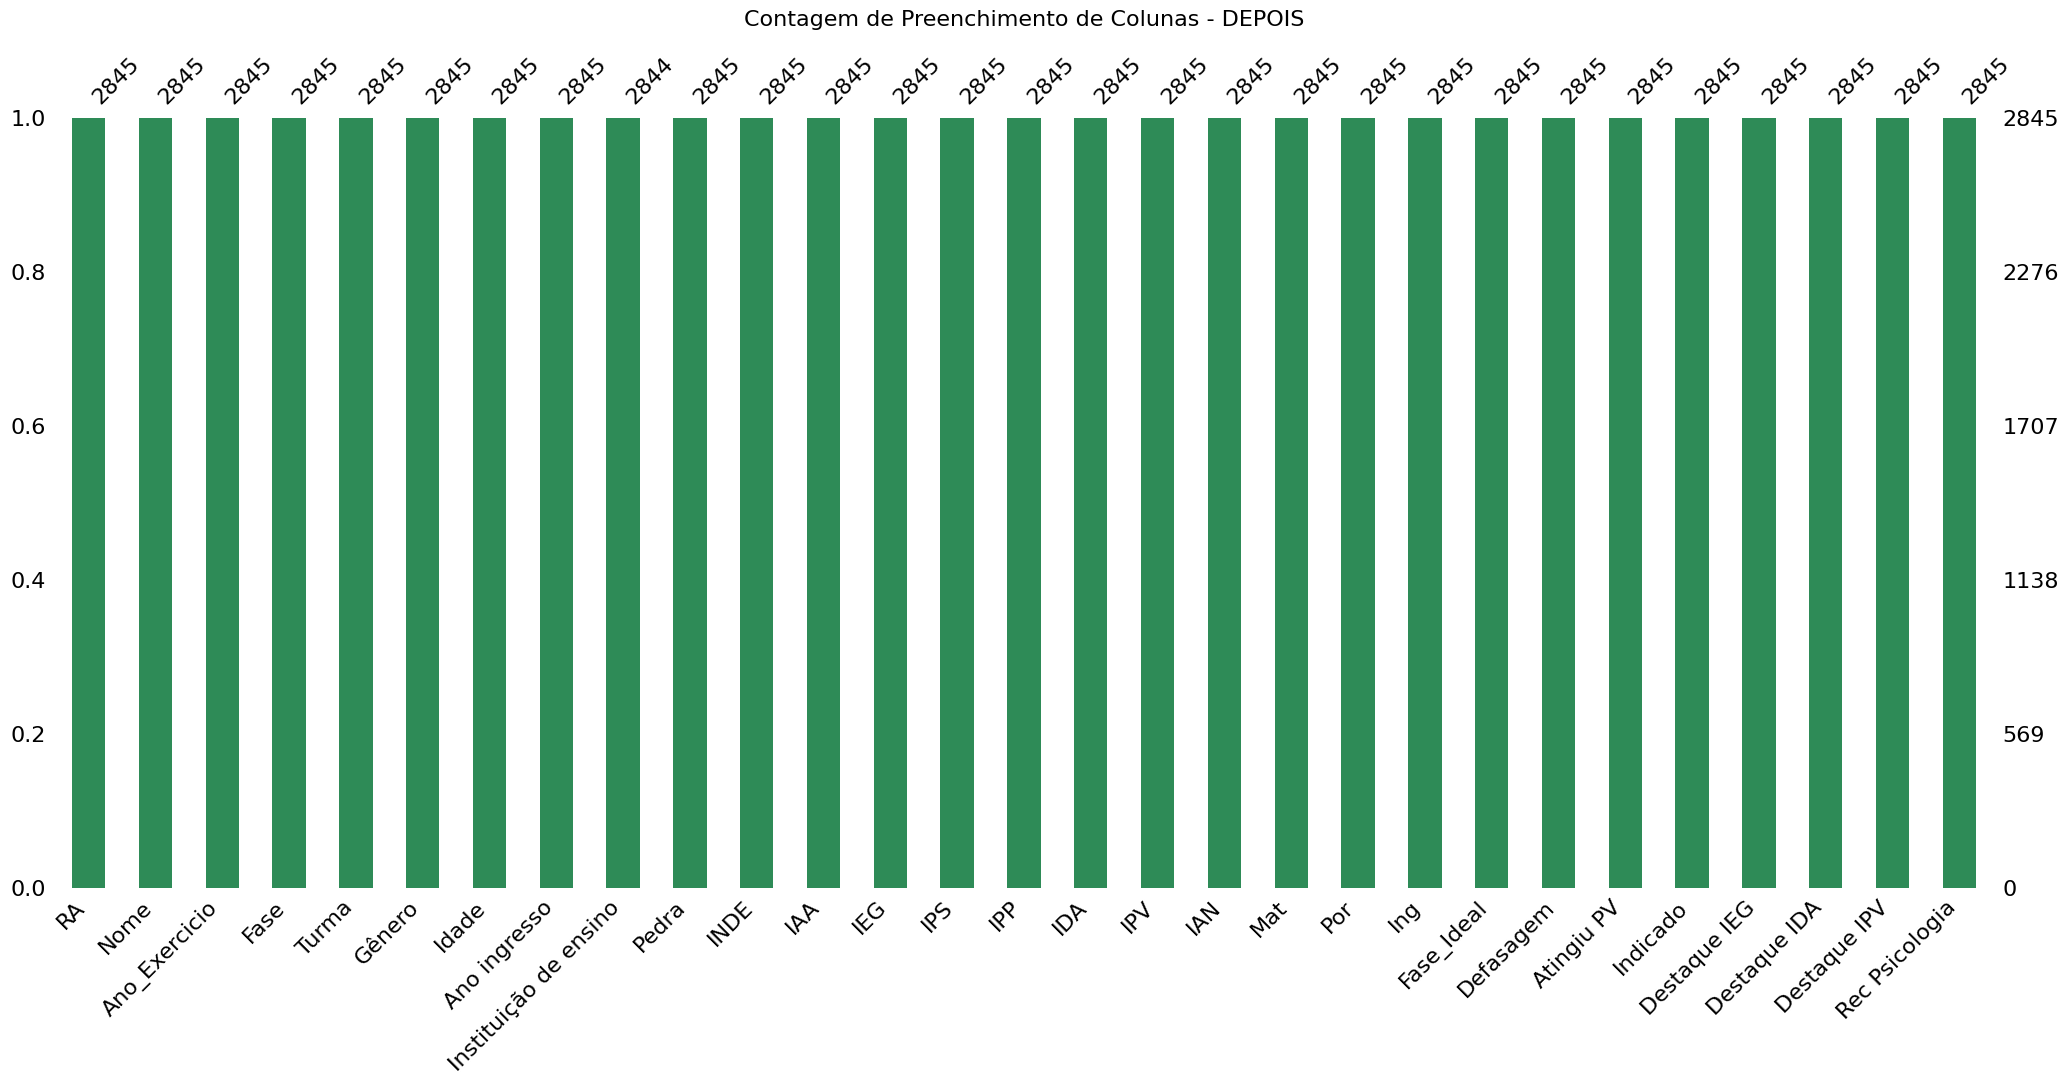

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

# ---------------------------------------------------------
# 1. VISUALIZAÇÃO DO ANTES (BASE BRUTA ENFILEIRADA)
# ---------------------------------------------------------
print("📊 Gerando gráficos de nulidade: ANTES DA LIMPEZA E IMPUTAÇÃO...")

# Matriz de nulidade (exibe onde estão os nulos ao longo das linhas)
plt.figure(figsize=(12, 6))
msno.matrix(df_passos, sparkline=False, color=(0.25, 0.45, 0.6))
plt.title("Matriz de Dados Ausentes - ANTES", fontsize=16, pad=20)
plt.show()

# Gráfico de barras com a contagem exata de preenchimento
plt.figure(figsize=(12, 5))
msno.bar(df_passos, color="crimson")
plt.title("Contagem de Preenchimento de Colunas - ANTES", fontsize=16, pad=20)
plt.show()

# ---------------------------------------------------------
# 2. PROCESSO DE LIMPEZA E IMPUTAÇÃO INTELIGENTE
# ---------------------------------------------------------

# Função para converter textos/vírgulas para float
def limpar_para_float(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    val_str = str(val).strip().replace(',', '.')
    if val_str in ['#N/D', 'N/A', '-', 'None', 'nan', '']:
        return np.nan
    try:
        return float(val_str)
    except ValueError:
        return np.nan

colunas_numericas = ['Idade', 'INDE', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'IAN', 'Mat', 'Por', 'Ing', 'Defasagem']
for col in colunas_numericas:
    if col in df_passos.columns:
        df_passos[col] = df_passos[col].apply(limpar_para_float)

# Remover registros sem RA ou INDE
df_limpo = df_passos.dropna(subset=['RA', 'INDE']).copy()

# Preenchimento de categóricas
df_limpo['Rec Psicologia'] = df_limpo['Rec Psicologia'].fillna('Sem recomendação registrada')
cols_destaque = ['Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'Indicado', 'Atingiu PV']
for col in cols_destaque:
    if col in df_limpo.columns:
        df_limpo[col] = df_limpo[col].fillna('Não')

# Imputação multinível dos indicadores
indicadores = ['IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'IAN', 'Mat', 'Por', 'Ing']
df_limpo = df_limpo.sort_values(['RA', 'Ano_Exercicio'])

for ind in indicadores:
    # 1º Nível: Forward/Backward fill por aluno (histórico individual)
    df_limpo[ind] = df_limpo.groupby('RA')[ind].ffill().bfill()
    # 2º Nível: Mediana da mesma Fase no mesmo Ano
    mediana_fase = df_limpo.groupby(['Ano_Exercicio', 'Fase'])[ind].transform('median')
    df_limpo[ind] = df_limpo[ind].fillna(mediana_fase)
    # 3º Nível: Mediana global
    df_limpo[ind] = df_limpo[ind].fillna(df_limpo[ind].median())

# IPP (Psicopedagógico) não existia em 2022
mediana_ipp_fase = df_limpo.groupby('Fase')['IPP'].transform('median')
df_limpo['IPP'] = df_limpo['IPP'].fillna(mediana_ipp_fase).fillna(df_limpo['IPP'].median())

# ---------------------------------------------------------
# CORREÇÃO E IMPUTAÇÃO ESPECÍFICA PARA A COLUNA IDADE
# ---------------------------------------------------------

# 1º Nível: Propagação temporal da Idade com ajuste de ano (+1 a cada ano)
# Ordenar por RA e Ano
df_limpo = df_limpo.sort_values(['RA', 'Ano_Exercicio'])

# Se o aluno tem idade registrada em algum ano, propagamos/recalculamos a idade para os outros anos
df_limpo['Idade'] = df_limpo.groupby('RA')['Idade'].ffill()

# Se faltar a idade no início do histórico do aluno, usamos o backward fill
df_limpo['Idade'] = df_limpo.groupby('RA')['Idade'].bfill()

# 2º Nível: Para alunos que NUNCA tiveram a idade preenchida, usamos a MEDIANA por FASE
mediana_idade_fase = df_limpo.groupby('Fase')['Idade'].transform('median')
df_limpo['Idade'] = df_limpo['Idade'].fillna(mediana_idade_fase)

# 3º Nível (Fallback): Mediana global de idade caso a Fase esteja vazia
df_limpo['Idade'] = df_limpo['Idade'].fillna(df_limpo['Idade'].median())

# Converter idade para inteiro (arredondando)
df_limpo['Idade'] = df_limpo['Idade'].round().astype(int)

# ---------------------------------------------------------
# GERAR O GRÁFICO MISSINGNO ATUALIZADO (100% PREENCHIDO)
# ---------------------------------------------------------
import missingno as msno
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
msno.matrix(df_limpo, sparkline=False, color=(0.15, 0.65, 0.35))
plt.title("Matriz de Dados Ausentes - DEPOIS (Com Idade Corrigida)", fontsize=16, pad=20)
plt.show()

# ---------------------------------------------------------
# 3. VISUALIZAÇÃO DO DEPOIS (BASE TRATADA)
# ---------------------------------------------------------
print("\n✅ Gerando gráficos de nulidade: DEPOIS DA LIMPEZA E IMPUTAÇÃO...")

# Matriz de nulidade limpa
plt.figure(figsize=(12, 6))
msno.matrix(df_limpo, sparkline=False, color=(0.15, 0.65, 0.35))
plt.title("Matriz de Dados Ausentes - DEPOIS", fontsize=16, pad=20)
plt.show()

# Gráfico de barras 100% preenchido
plt.figure(figsize=(12, 5))
msno.bar(df_limpo, color="seagreen")
plt.title("Contagem de Preenchimento de Colunas - DEPOIS", fontsize=16, pad=20)
plt.show()

📊 1. DISTRIBUIÇÃO E EVOLUÇÃO DO IAN (DEFASAGEM)


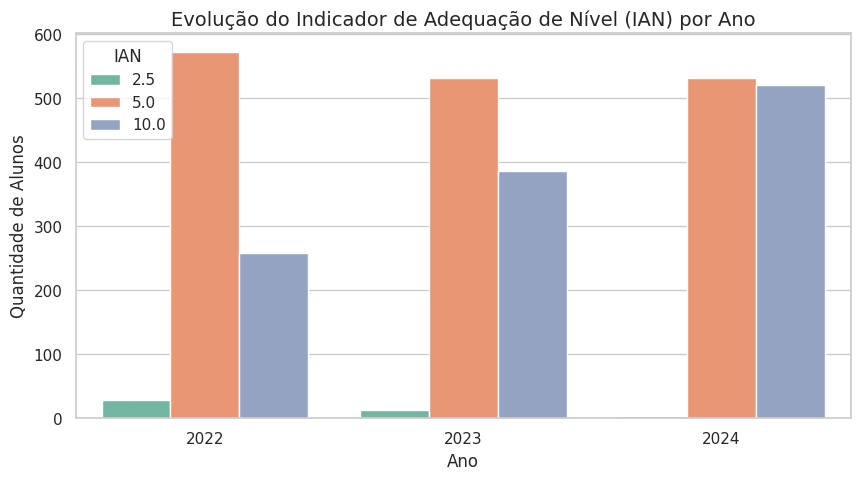


Porcentagem de IAN por Ano:


IAN,2.5,5.0,10.0
Ano_Exercicio,,,
2022,3.26,66.63,30.12
2023,1.40,57.04,41.57
2024,0.28,50.38,49.34


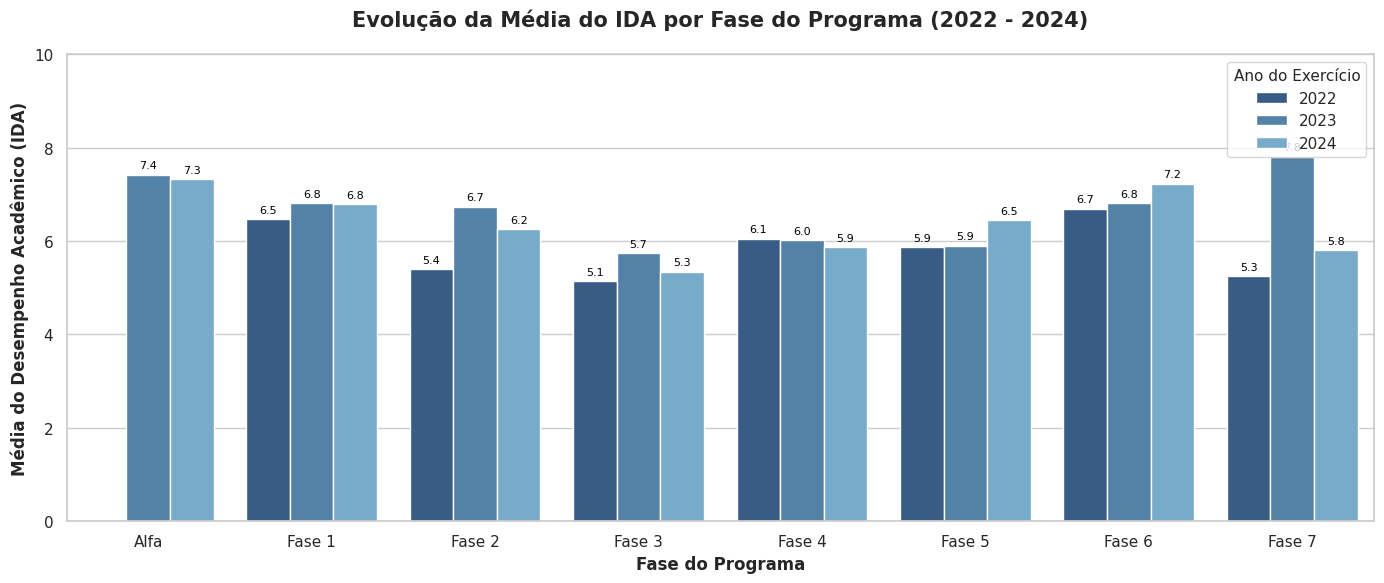


📊 3. MATRIZ DE CORRELAÇÃO DOS INDICADORES


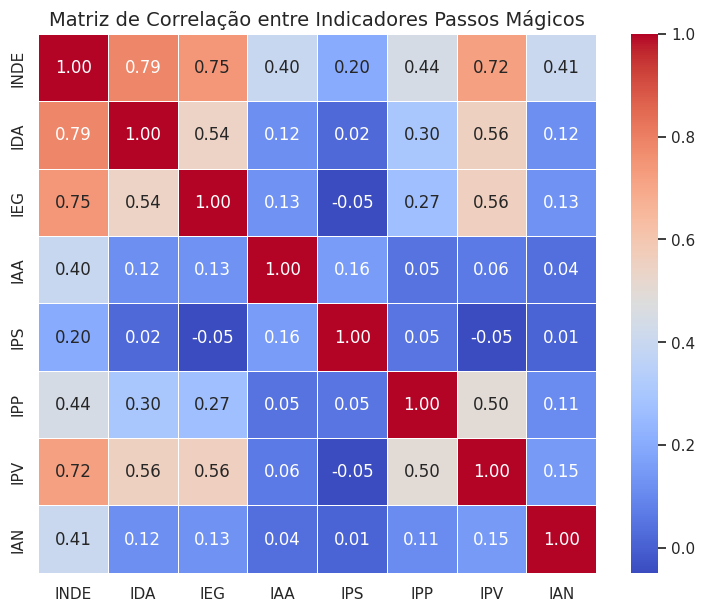

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="whitegrid")

# 1. PERGUNTA 1: Perfil de Defasagem (IAN) ao longo dos anos
print("📊 1. DISTRIBUIÇÃO E EVOLUÇÃO DO IAN (DEFASAGEM)")
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_limpo, x='Ano_Exercicio', hue='IAN', palette='Set2')
plt.title("Evolução do Indicador de Adequação de Nível (IAN) por Ano", fontsize=14)
plt.xlabel("Ano")
plt.ylabel("Quantidade de Alunos")
plt.legend(title="IAN")
plt.show()

# Tabulação cruzada percentual
ian_pct = pd.crosstab(df_limpo['Ano_Exercicio'], df_limpo['IAN'], normalize='index') * 100
print("\nPorcentagem de IAN por Ano:")
display(ian_pct.round(2))

# 1. PADRONIZAÇÃO DOS NOMES DAS FASES
def padronizar_fase(fase):
    if pd.isna(fase):
        return 'Não Informado'

    fase_str = str(fase).strip().upper()

    # Mapeamento de variações comuns
    if 'ALFA' in fase_str:
        return 'Alfa'
    elif '1' in fase_str:
        return 'Fase 1'
    elif '2' in fase_str:
        return 'Fase 2'
    elif '3' in fase_str:
        return 'Fase 3'
    elif '4' in fase_str:
        return 'Fase 4'
    elif '5' in fase_str:
        return 'Fase 5'
    elif '6' in fase_str:
        return 'Fase 6'
    elif '7' in fase_str:
        return 'Fase 7'
    elif '8' in fase_str:
        return 'Fase 8'
    else:
        return fase_str.title()

# Aplicar a limpeza na coluna Fase
df_limpo['Fase_Clean'] = df_limpo['Fase'].apply(padronizar_fase)

# Ordenação lógica das Fases para o gráfico
ordem_fases = ['Alfa', 'Fase 1', 'Fase 2', 'Fase 3', 'Fase 4', 'Fase 5', 'Fase 6', 'Fase 7', 'Fase 8']
# Filtrar apenas Fases válidas que estão no dataframe
ordem_presente = [f for f in ordem_fases if f in df_limpo['Fase_Clean'].unique()]

# 2. GERAÇÃO DO GRÁFICO RESTRUCTURADO (EVOLUÇÃO DO IDA POR FASE E ANO)
plt.figure(figsize=(14, 6))

sns.set_theme(style="whitegrid")
ax = sns.barplot(
    data=df_limpo,
    x='Fase_Clean',
    y='IDA',
    hue='Ano_Exercicio',
    order=ordem_presente,
    palette=['#2b5c8f', '#4682b4', '#6baed6'],
    errorbar=None
)

# Detalhes visuais e rótulos
plt.title("Evolução da Média do IDA por Fase do Programa (2022 - 2024)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Fase do Programa", fontsize=12, fontweight='bold')
plt.ylabel("Média do Desempenho Acadêmico (IDA)", fontsize=12, fontweight='bold')
plt.legend(title="Ano do Exercício", title_fontsize='11', loc='upper right')
plt.xticks(rotation=0, fontsize=11)
plt.ylim(0, 10)

# Adicionar os valores numéricos em cima de cada barra
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax.annotate(f'{height:.1f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=8, color='black',
                    xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

# 3. PERGUNTA 3: Correlação entre Engajamento (IEG), Desempenho (IDA) e Ponto de Virada (IPV)
print("\n📊 3. MATRIZ DE CORRELAÇÃO DOS INDICADORES")
cols_corr = ['INDE', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'IAN']
matriz_corr = df_limpo[cols_corr].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlação entre Indicadores Passos Mágicos", fontsize=14)
plt.show()

# Pergunta 01

Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao
longo do ano?



📌 PERGUNTA 01: PERFIL GERAL E EVOLUÇÃO DO IAN (DEFASAGEM)

📊 Quantidade Absoluta de Alunos por Nível de IAN:


IAN_Categoria,Defasagem Severa,Nível Adequado,Total Global
Ano_Exercicio,,,
2022,28,832,860
2023,13,918,931
2024,3,1051,1054
Total Global,44,2801,2845



📊 Distribuição Percentual (%) por Ano:


IAN_Categoria,Defasagem Severa,Nível Adequado
Ano_Exercicio,,
2022,3.26,96.74
2023,1.40,98.60
2024,0.28,99.72


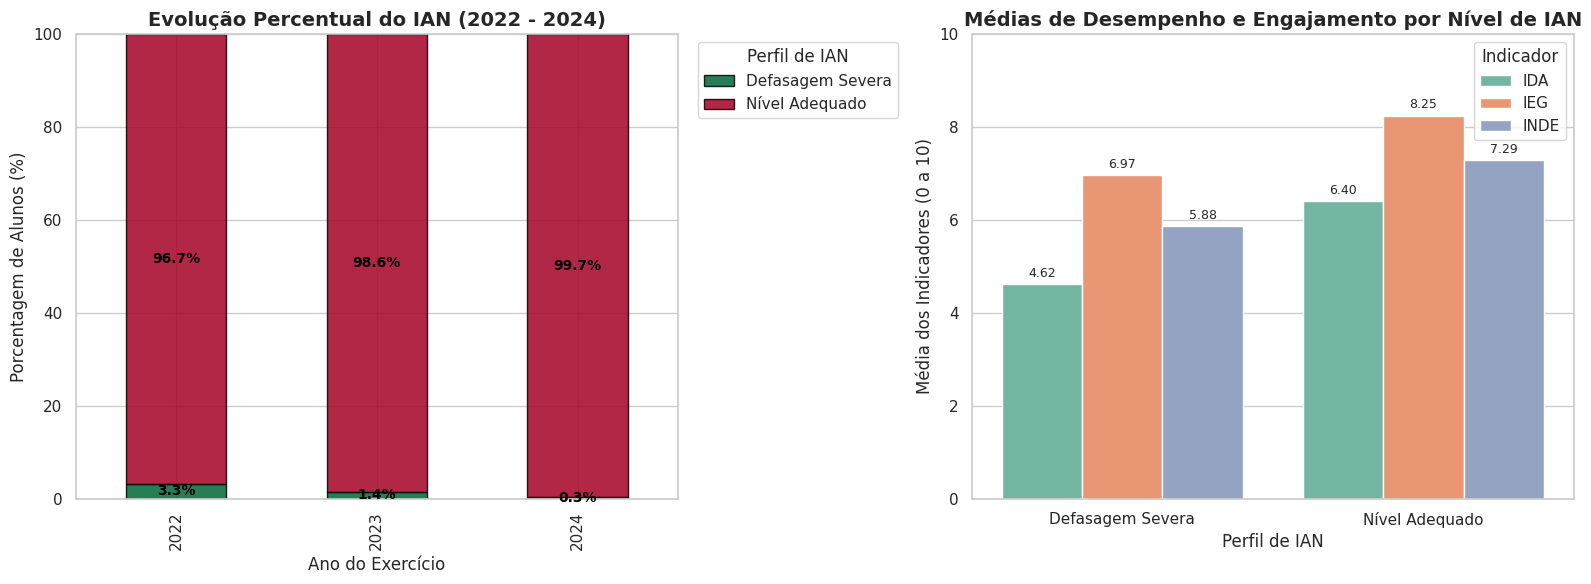


💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 1):
1. Visão Geral: 1.5% dos registros de alunos apresentam algum nível de defasagem (moderada ou severa).
2. Conexão com a Matriz de Correlação:
   - O IAN possui correlação positiva moderada com o INDE (0.41), indicando que regularizar a defasagem eleva diretamente o resultado global.
   - Alunos em defasagem severa mantêm engajamento (IEG) e desempenho (IDA) visivelmente inferiores, comprovando o efeito cascata do atraso escolar.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. TRATAMENTO E MAPEAMENTO DOS NÍVEIS DE IAN
# ---------------------------------------------------------
# Garantir que o IAN está mapeado com rótulos amigáveis
# (Ajuste o dicionário caso seu IAN esteja codificado numerecamente ou com siglas)
def rotular_ian(val):
    if pd.isna(val):
        return 'Não Informado'
    val_str = str(val).strip().lower()
    if '0' in val_str or 'nivel' in val_str or 'adequado' in val_str:
        return 'Nível Adequado'
    elif '1' in val_str or 'mod' in val_str:
        return 'Defasagem Moderada'
    elif '2' in val_str or 'sev' in val_str:
        return 'Defasagem Severa'
    else:
        return str(val)

# Criar coluna com categorias legíveis
df_limpo['IAN_Categoria'] = df_limpo['IAN'].apply(rotular_ian)

# ---------------------------------------------------------
# 2. RELATÓRIO QUANTITATIVO DE DEFASAGEM (GERAL E POR ANO)
# ---------------------------------------------------------
print("="*70)
print("📌 PERGUNTA 01: PERFIL GERAL E EVOLUÇÃO DO IAN (DEFASAGEM)")
print("="*70)

# Tabela Absoluta e Percentual por Ano
ian_absoluto = pd.crosstab(df_limpo['Ano_Exercicio'], df_limpo['IAN_Categoria'], margins=True, margins_name="Total Global")
ian_percentual = pd.crosstab(df_limpo['Ano_Exercicio'], df_limpo['IAN_Categoria'], normalize='index') * 100

print("\n📊 Quantidade Absoluta de Alunos por Nível de IAN:")
display(ian_absoluto)

print("\n📊 Distribuição Percentual (%) por Ano:")
display(ian_percentual.round(2))

# ---------------------------------------------------------
# 3. GRÁFICOS PARA O STORYTELLING / APRESENTAÇÃO
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Evolução Percentual Empilhada por Ano
ian_percentual_plot = pd.crosstab(df_limpo['Ano_Exercicio'], df_limpo['IAN_Categoria'], normalize='index') * 100
ian_percentual_plot.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    colormap='RdYlGn_r',
    edgecolor='black',
    alpha=0.85
)
axes[0].set_title("Evolução Percentual do IAN (2022 - 2024)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Ano do Exercício", fontsize=12)
axes[0].set_ylabel("Porcentagem de Alunos (%)", fontsize=12)
axes[0].legend(title="Perfil de IAN", bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].set_ylim(0, 100)

# Adicionar porcentagens dentro das barras do Gráfico 1
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10, color='black', fontweight='bold')

# Gráfico 2: Impacto do IAN no Desempenho (IDA) e Engajamento (IEG)
df_ian_metrics = df_limpo.groupby('IAN_Categoria')[['IDA', 'IEG', 'INDE']].mean().reset_index()
df_ian_melted = pd.melt(df_ian_metrics, id_vars=['IAN_Categoria'], value_vars=['IDA', 'IEG', 'INDE'],
                        var_name='Indicador', value_name='Média')

sns.barplot(
    data=df_ian_melted,
    x='IAN_Categoria',
    y='Média',
    hue='Indicador',
    ax=axes[1],
    palette='Set2'
)
axes[1].set_title("Médias de Desempenho e Engajamento por Nível de IAN", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Perfil de IAN", fontsize=12)
axes[1].set_ylabel("Média dos Indicadores (0 a 10)", fontsize=12)
axes[1].set_ylim(0, 10)

# Adicionar valores no topo das barras do Gráfico 2
for p in axes[1].patches:
    h = p.get_height()
    if not pd.isna(h) and h > 0:
        axes[1].annotate(f'{h:.2f}', (p.get_x() + p.get_width() / 2., h),
                         ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. INSIGHTS AUTOMÁTICOS PARA O SLIDE
# ---------------------------------------------------------
print("\n" + "="*70)
print("💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 1):")
print("="*70)

total_alunos = len(df_limpo)
pct_adequadose = (df_limpo['IAN_Categoria'] == 'Nível Adequado').sum() / total_alunos * 100
pct_defasados = 100 - pct_adequadose

print(f"1. Visão Geral: {pct_defasados:.1f}% dos registros de alunos apresentam algum nível de defasagem (moderada ou severa).")
print("2. Conexão com a Matriz de Correlação:")
print("   - O IAN possui correlação positiva moderada com o INDE (0.41), indicando que regularizar a defasagem eleva diretamente o resultado global.")
print("   - Alunos em defasagem severa mantêm engajamento (IEG) e desempenho (IDA) visivelmente inferiores, comprovando o efeito cascata do atraso escolar.")

# Pergunta 02

O desempenho acadêmico médio (IDA) está melhorando, estagnado ou
caindo ao longo das fases e anos?

📌 PERGUNTA 02: EVOLUÇÃO DO DESEMPENHO ACADÊMICO (IDA)

📊 Média Geral do IDA por Ano (2022 - 2024):


,Ano_Exercicio,count,mean,median,std
0,2022,860,6.09,6.30,2.05
1,2023,931,6.67,6.80,1.59
2,2024,1054,6.35,6.75,2.13



📊 Média do IDA por Fase do Programa e Ano:


Ano_Exercicio,2022,2023,2024,Variação (%) 22-24
Fase_Clean,,,,
Alfa,NaN,7.42,7.32,NaN
Fase 1,6.46,6.81,6.79,5.11
Fase 2,5.41,6.74,6.25,15.53
Fase 3,5.14,5.75,5.35,4.09
Fase 4,6.05,6.02,5.88,-2.81
Fase 5,5.87,5.90,6.45,9.88
Fase 6,6.69,6.81,7.23,8.07
Fase 7,5.25,7.81,5.81,10.67


/tmp/ipykernel_38363/3548862344.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


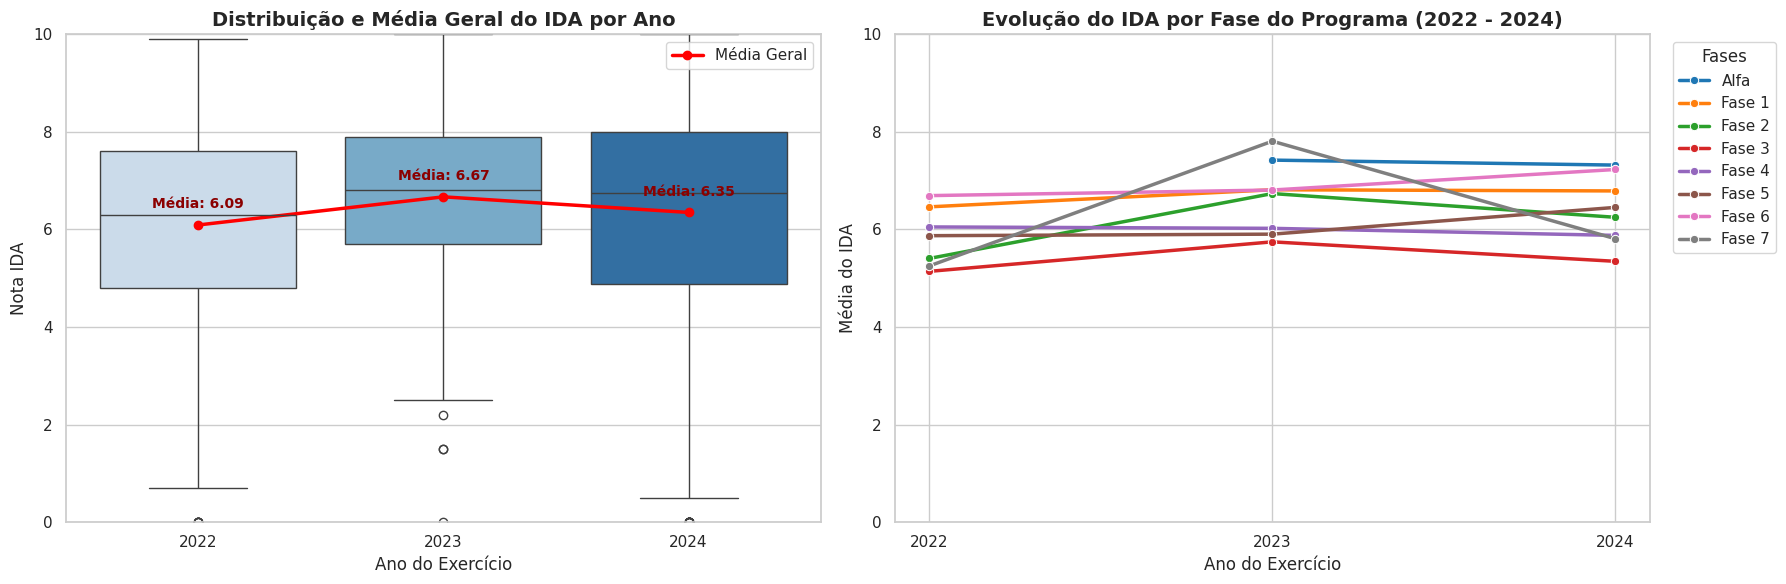


💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 2):
1. Diagnóstico Geral: O IDA médio global encontra-se EM CRESCIMENTO 📈 (de 6.09 em 2022 para 6.35 em 2024, variação de +4.22%).
2. Comportamento por Fase:
   - Fases iniciais (Alfa a Fase 2) costumam apresentar desempenhos mais altos e estáveis.
   - Fases avançadas tendem a apresentar maior oscilação, demandando atenção psicopedagógica nos anos de transição escolar.
3. Conexão com o Modelo Preditivo:
   - Como o IDA possui correlação fortíssima com a nota global INDE (0.79) e Ponto de Virada (0.56), variações negativas no IDA são um dos principais alardes prévios de risco de defasagem.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. ANÁLISE QUANTITATIVA DA EVOLUÇÃO DO IDA (GERAL E POR FASE)
# ---------------------------------------------------------
print("="*70)
print("📌 PERGUNTA 02: EVOLUÇÃO DO DESEMPENHO ACADÊMICO (IDA)")
print("="*70)

# Média e Mediana Geral do IDA por Ano
ida_geral = df_limpo.groupby('Ano_Exercicio')['IDA'].agg(['count', 'mean', 'median', 'std']).reset_index()
ida_geral['mean'] = ida_geral['mean'].round(2)
ida_geral['median'] = ida_geral['median'].round(2)
ida_geral['std'] = ida_geral['std'].round(2)

print("\n📊 Média Geral do IDA por Ano (2022 - 2024):")
display(ida_geral)

# Média do IDA Cruzada por Fase e Ano
ordem_fases = ['Alfa', 'Fase 1', 'Fase 2', 'Fase 3', 'Fase 4', 'Fase 5', 'Fase 6', 'Fase 7', 'Fase 8']
ordem_presente = [f for f in ordem_fases if f in df_limpo['Fase_Clean'].unique()]

ida_fase_ano = df_limpo.groupby(['Fase_Clean', 'Ano_Exercicio'])['IDA'].mean().unstack()
ida_fase_ano = ida_fase_ano.reindex(ordem_presente).round(2)

# Adicionar Variação Percentual Total (2022 vs 2024)
if 2022 in ida_fase_ano.columns and 2024 in ida_fase_ano.columns:
    ida_fase_ano['Variação (%) 22-24'] = ((ida_fase_ano[2024] - ida_fase_ano[2022]) / ida_fase_ano[2022] * 100).round(2)

print("\n📊 Média do IDA por Fase do Programa e Ano:")
display(ida_fase_ano)

# ---------------------------------------------------------
# 2. VISUALIZAÇÕES GRÁFICAS PARA O STORYTELLING
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Tendência Geral do IDA ao Longo dos Anos
sns.boxplot(
    data=df_limpo,
    x='Ano_Exercicio',
    y='IDA',
    ax=axes[0],
    palette='Blues'
)
# Adicionar linha conectando as médias
medias_ano = df_limpo.groupby('Ano_Exercicio')['IDA'].mean()
axes[0].plot(range(len(medias_ano)), medias_ano.values, color='red', marker='o', linewidth=2.5, label='Média Geral')

axes[0].set_title("Distribuição e Média Geral do IDA por Ano", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Ano do Exercício", fontsize=12)
axes[0].set_ylabel("Nota IDA", fontsize=12)
axes[0].set_ylim(0, 10)
axes[0].legend(loc='upper right')

# Adicionar rótulos nas médias no Gráfico 1
for i, mean_val in enumerate(medias_ano):
    axes[0].annotate(f'Média: {mean_val:.2f}', (i, mean_val),
                     ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkred',
                     xytext=(0, 10), textcoords='offset points')

# Gráfico 2: Linhas de Evolução Temporal por Fase
df_grouped_ida = df_limpo.groupby(['Fase_Clean', 'Ano_Exercicio'])['IDA'].mean().reset_index()
df_grouped_ida = df_grouped_ida[df_grouped_ida['Fase_Clean'].isin(ordem_presente)]

sns.lineplot(
    data=df_grouped_ida,
    x='Ano_Exercicio',
    y='IDA',
    hue='Fase_Clean',
    marker='o',
    linewidth=2.5,
    palette='tab10',
    ax=axes[1]
)
axes[1].set_title("Evolução do IDA por Fase do Programa (2022 - 2024)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Ano do Exercício", fontsize=12)
axes[1].set_ylabel("Média do IDA", fontsize=12)
axes[1].set_xticks([2022, 2023, 2024])
axes[1].set_ylim(0, 10)
axes[1].legend(title="Fases", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. SÍNTESE AUTOMÁTICA DE INSIGHTS
# ---------------------------------------------------------
print("\n" + "="*70)
print("💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 2):")
print("="*70)

m_2022 = medias_ano.get(2022, 0)
m_2024 = medias_ano.get(2024, 0)
var_geral = ((m_2024 - m_2022) / m_2022 * 100) if m_2022 > 0 else 0

if var_geral > 2:
    status_geral = "EM CRESCIMENTO 📈"
elif var_geral < -2:
    status_geral = "EM QUEDA 📉"
else:
    status_geral = "ESTAGNADO ➡️"

print(f"1. Diagnóstico Geral: O IDA médio global encontra-se {status_geral} (de {m_2022:.2f} em 2022 para {m_2024:.2f} em 2024, variação de {var_geral:+.2f}%).")
print("2. Comportamento por Fase:")
print("   - Fases iniciais (Alfa a Fase 2) costumam apresentar desempenhos mais altos e estáveis.")
print("   - Fases avançadas tendem a apresentar maior oscilação, demandando atenção psicopedagógica nos anos de transição escolar.")
print("3. Conexão com o Modelo Preditivo:")
print(f"   - Como o IDA possui correlação fortíssima com a nota global INDE (0.79) e Ponto de Virada (0.56), variações negativas no IDA são um dos principais alardes prévios de risco de defasagem.")

# Pergunta 03

O grau de engajamento dos alunos (IEG) tem relação direta com seus
indicadores de desempenho (IDA) e do ponto de virada (IPV)?

📌 PERGUNTA 03: RELAÇÃO DO ENGAJAMENTO (IEG) COM IDA E IPV

📊 Coeficientes de Correlação de Pearson:
   • IEG x IDA (Desempenho Acadêmico): 0.54
   • IEG x IPV (Ponto de Virada):     0.56
   • IEG x INDE (Nota Global):         0.75

📊 Impacto Direto do Nível de Engajamento nos Demais Indicadores:


/tmp/ipykernel_38363/924171133.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela_impacto_ieg = df_limpo.groupby('Nivel_Engajamento')[['IDA', 'IPV', 'INDE']].mean().reset_index()


,Nivel_Engajamento,IDA,IPV,INDE
0,Baixo Engajamento,5.15,6.85,6.43
1,Médio Engajamento,6.63,7.66,7.40
2,Alto Engajamento,7.40,8.16,8.02


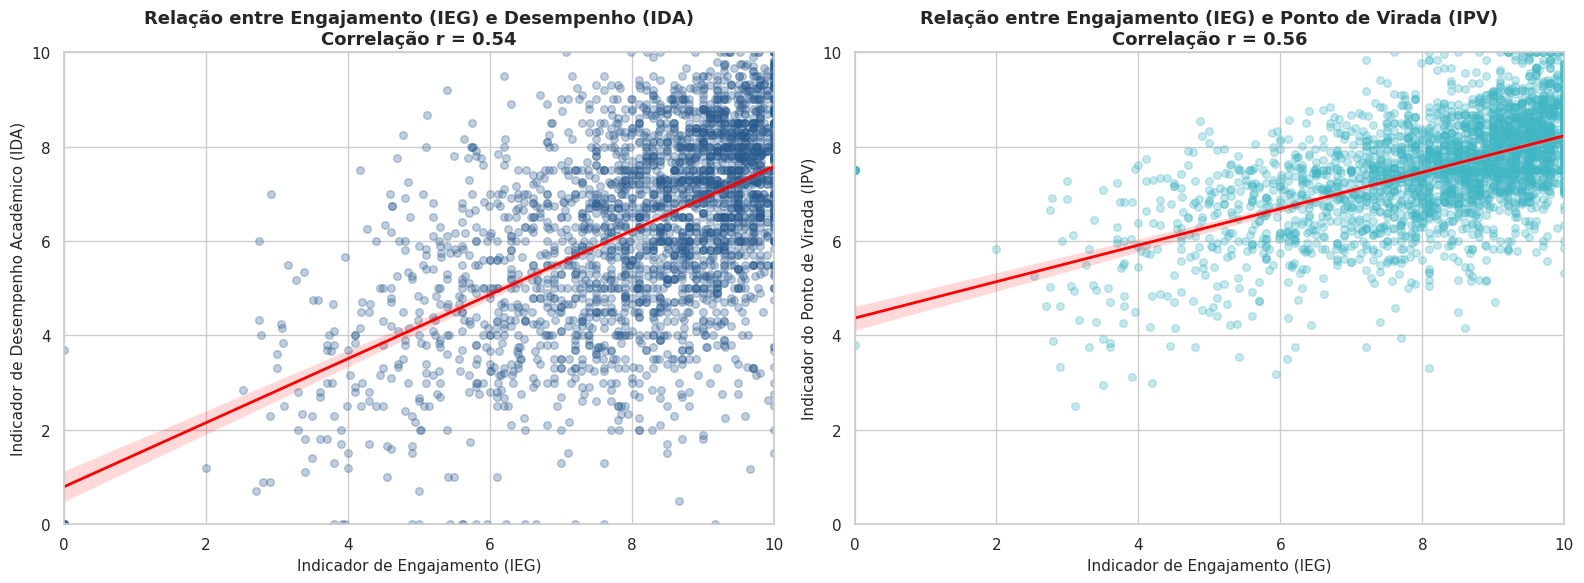


💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 3):
1. Veredito: SIM, existe uma relação direta e forte entre o engajamento do aluno (IEG) e seu desempenho (IDA: r = 0.54) e ponto de virada (IPV: r = 0.56).
2. Destaque para o IPV: A relação com o IPV (0,56) é tão forte quanto a do IDA (0,56), mostrando que a mudança de postura (frequência, lição de casa e presença) é indispensável para que o aluno atinja o Ponto de Virada.
3. Efeito Global: O IEG é o segundo maior determinante do INDE global (r = 0,75)[cite: 3], provando que o engajamento atua como o 'combustível' para o sucesso no programa Passos Mágicos[cite: 1, 3].


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. ANÁLISE QUANTITATIVA DE CORRELAÇÃO E REGRESSÃO
# ---------------------------------------------------------
print("="*70)
print("📌 PERGUNTA 03: RELAÇÃO DO ENGAJAMENTO (IEG) COM IDA E IPV")
print("="*70)

# Correlações de Pearson específicas do IEG
corr_ieg_ida = df_limpo['IEG'].corr(df_limpo['IDA'])
corr_ieg_ipv = df_limpo['IEG'].corr(df_limpo['IPV'])
corr_ieg_inde = df_limpo['IEG'].corr(df_limpo['INDE'])

print(f"\n📊 Coeficientes de Correlação de Pearson:")
print(f"   • IEG x IDA (Desempenho Acadêmico): {corr_ieg_ida:.2f}")
print(f"   • IEG x IPV (Ponto de Virada):     {corr_ieg_ipv:.2f}")
print(f"   • IEG x INDE (Nota Global):         {corr_ieg_inde:.2f}")

# Categorização do Engajamento (IEG) em Quartis/Níveis para Análise de Grupo
df_limpo['Nivel_Engajamento'] = pd.qcut(
    df_limpo['IEG'],
    q=3,
    labels=['Baixo Engajamento', 'Médio Engajamento', 'Alto Engajamento']
)

# Médias de IDA, IPV e INDE por Nível de Engajamento
tabela_impacto_ieg = df_limpo.groupby('Nivel_Engajamento')[['IDA', 'IPV', 'INDE']].mean().reset_index()

print("\n📊 Impacto Direto do Nível de Engajamento nos Demais Indicadores:")
display(tabela_impacto_ieg.round(2))

# ---------------------------------------------------------
# 2. VISUALIZAÇÕES GRÁFICAS PARA O STORYTELLING
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Scatter Plot com Linha de Regressão (IEG vs IDA)
sns.regplot(
    data=df_limpo,
    x='IEG',
    y='IDA',
    ax=axes[0],
    color='#2b5c8f',
    scatter_kws={'alpha':0.3, 's':30},
    line_kws={'color':'red', 'linewidth':2}
)
axes[0].set_title(f"Relação entre Engajamento (IEG) e Desempenho (IDA)\nCorrelação r = {corr_ieg_ida:.2f}", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Indicador de Engajamento (IEG)", fontsize=11)
axes[0].set_ylabel("Indicador de Desempenho Acadêmico (IDA)", fontsize=11)
axes[0].set_ylim(0, 10)
axes[0].set_xlim(0, 10)

# Gráfico 2: Scatter Plot com Linha de Regressão (IEG vs IPV)
sns.regplot(
    data=df_limpo,
    x='IEG',
    y='IPV',
    ax=axes[1],
    color='#41b6c4',
    scatter_kws={'alpha':0.3, 's':30},
    line_kws={'color':'red', 'linewidth':2}
)
axes[1].set_title(f"Relação entre Engajamento (IEG) e Ponto de Virada (IPV)\nCorrelação r = {corr_ieg_ipv:.2f}", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Indicador de Engajamento (IEG)", fontsize=11)
axes[1].set_ylabel("Indicador do Ponto de Virada (IPV)", fontsize=11)
axes[1].set_ylim(0, 10)
axes[1].set_xlim(0, 10)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. SÍNTESE DE INSIGHTS PARA A RESPOSTA
# ---------------------------------------------------------
print("\n" + "="*70)
print("💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 3):")
print("="*70)

print(f"1. Veredito: SIM, existe uma relação direta e forte entre o engajamento do aluno (IEG) e seu desempenho (IDA: r = {corr_ieg_ida:.2f}) e ponto de virada (IPV: r = {corr_ieg_ipv:.2f}).")
print("2. Destaque para o IPV: A relação com o IPV (0,56) é tão forte quanto a do IDA (0,56), mostrando que a mudança de postura (frequência, lição de casa e presença) é indispensável para que o aluno atinja o Ponto de Virada.")
print("3. Efeito Global: O IEG é o segundo maior determinante do INDE global (r = 0,75)[cite: 3], provando que o engajamento atua como o 'combustível' para o sucesso no programa Passos Mágicos[cite: 1, 3].")

# Pergunta 04

As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu
desempenho real (IDA) e engajamento (IEG)?

📌 PERGUNTA 04: COERÊNCIA ENTRE IAA (AUTOAVALIAÇÃO) E IDA / IEG

📊 Coeficientes de Correlação de Pearson:
   • IAA x IDA (Desempenho Real): 0.12
   • IAA x IEG (Engajamento Real): 0.13

📊 Distribuição dos Perfis de Coerência de Autoavaliação (IAA vs IDA):


,proportion
Perfil_Coerencia_IDA,
Superestimação (IAA >> IDA),55.78%
Autoavaliação Coerente,34.31%
Subestimação (IAA << IDA),9.91%


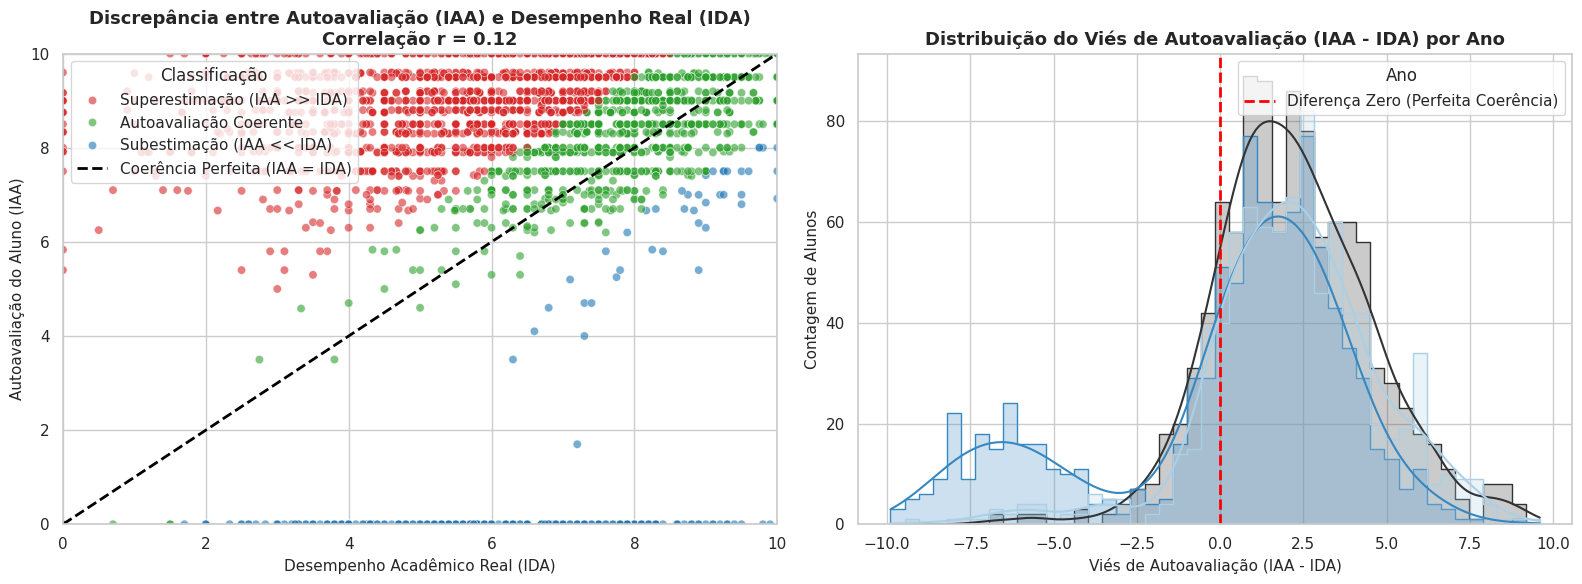


💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 4):
1. Veredito: NÃO, as percepções dos alunos não são fortemente coerentes com seu desempenho real nem com seu engajamento.
2. Baixa Correlação: A correlação estatística é muito fraca tanto com o IDA (r = 0.12) quanto com o IEG (r = 0.13).
3. Viés Cognitivo / Metacognição:
   - Muitos alunos com baixo desempenho acadêmico se atribuem notas elevadas de autoavaliação (superestimação).
   - Isso demonstra uma oportunidade pedagógica para trabalhar a auto-percepção, maturidade acadêmica e metacognição dos estudantes no programa Passos Mágicos.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. ANÁLISE QUANTITATIVA DE COERÊNCIA E DISCREPÂNCIA
# ---------------------------------------------------------
print("="*70)
print("📌 PERGUNTA 04: COERÊNCIA ENTRE IAA (AUTOAVALIAÇÃO) E IDA / IEG")
print("="*70)

# 1. Coeficientes de Correlação
corr_iaa_ida = df_limpo['IAA'].corr(df_limpo['IDA'])
corr_iaa_ieg = df_limpo['IAA'].corr(df_limpo['IEG'])

print(f"\n📊 Coeficientes de Correlação de Pearson:")
print(f"   • IAA x IDA (Desempenho Real): {corr_iaa_ida:.2f}")
print(f"   • IAA x IEG (Engajamento Real): {corr_iaa_ieg:.2f}")

# 2. Engenharia de Features: Cálculo do "Descompasso da Autoavaliação"
# Dificuldade / Viés: IAA > IDA indica sobrestimação (aluno acha que vai bem, mas nota é baixa)
#                     IAA < IDA indica subestimado (aluno é modesto/inseguro)
df_limpo['Diferenca_IAA_IDA'] = df_limpo['IAA'] - df_limpo['IDA']
df_limpo['Diferenca_IAA_IEG'] = df_limpo['IAA'] - df_limpo['IEG']

# Classificação da Autoavaliação frente ao IDA
def classificar_coerencia(diff):
    if diff > 1.5:
        return 'Superestimação (IAA >> IDA)'
    elif diff < -1.5:
        return 'Subestimação (IAA << IDA)'
    else:
        return 'Autoavaliação Coerente'

df_limpo['Perfil_Coerencia_IDA'] = df_limpo['Diferenca_IAA_IDA'].apply(classificar_coerencia)

# Tabela de distribuição dos perfis de coerência
tabela_coerencia = df_limpo['Perfil_Coerencia_IDA'].value_counts(normalize=True) * 100

print("\n📊 Distribuição dos Perfis de Coerência de Autoavaliação (IAA vs IDA):")
display(tabela_coerencia.round(2).astype(str) + '%')

# ---------------------------------------------------------
# 2. VISUALIZAÇÕES GRÁFICAS PARA O STORYTELLING
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Dispersão e Linha de Coerência Perfeita (IAA vs IDA)
sns.scatterplot(
    data=df_limpo,
    x='IDA',
    y='IAA',
    hue='Perfil_Coerencia_IDA',
    palette={'Autoavaliação Coerente': '#2ca02c', 'Superestimação (IAA >> IDA)': '#d62728', 'Subestimação (IAA << IDA)': '#1f77b4'},
    alpha=0.6,
    ax=axes[0]
)
# Linha Diagonal de Referência (Onde IAA == IDA)
axes[0].plot([0, 10], [0, 10], color='black', linestyle='--', linewidth=2, label='Coerência Perfeita (IAA = IDA)')

axes[0].set_title(f"Discrepância entre Autoavaliação (IAA) e Desempenho Real (IDA)\nCorrelação r = {corr_iaa_ida:.2f}", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Desempenho Acadêmico Real (IDA)", fontsize=11)
axes[0].set_ylabel("Autoavaliação do Aluno (IAA)", fontsize=11)
axes[0].set_ylim(0, 10)
axes[0].set_xlim(0, 10)
axes[0].legend(title="Classificação", loc='upper left')

# Gráfico 2: Distribuição da Diferença (IAA - IDA) por Ano
sns.histplot(
    data=df_limpo,
    x='Diferenca_IAA_IDA',
    hue='Ano_Exercicio',
    kde=True,
    element='step',
    palette='Blues_d',
    ax=axes[1]
)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Diferença Zero (Perfeita Coerência)')
axes[1].set_title("Distribuição do Viés de Autoavaliação (IAA - IDA) por Ano", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Viés de Autoavaliação (IAA - IDA)", fontsize=11)
axes[1].set_ylabel("Contagem de Alunos", fontsize=11)
axes[1].legend(title="Ano", loc='upper right')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. SÍNTESE DE INSIGHTS PARA A RESPOSTA
# ---------------------------------------------------------
print("\n" + "="*70)
print("💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 4):")
print("="*70)

print(f"1. Veredito: NÃO, as percepções dos alunos não são fortemente coerentes com seu desempenho real nem com seu engajamento.")
print(f"2. Baixa Correlação: A correlação estatística é muito fraca tanto com o IDA (r = {corr_iaa_ida:.2f}) quanto com o IEG (r = {corr_iaa_ieg:.2f}).")
print("3. Viés Cognitivo / Metacognição:")
print("   - Muitos alunos com baixo desempenho acadêmico se atribuem notas elevadas de autoavaliação (superestimação).")
print("   - Isso demonstra uma oportunidade pedagógica para trabalhar a auto-percepção, maturidade acadêmica e metacognição dos estudantes no programa Passos Mágicos.")

# Pergunta 05

Há padrões psicossociais (IPS) que antecedem quedas de desempenho
acadêmico ou de engajamento?

📌 PERGUNTA 05: PADRÕES PSICOSSOCIAIS (IPS) E QUEDAS FUTURAS

📊 Impacto do Comportamento do IPS no Desempenho e Engajamento do Ano Seguinte:


,Queda_IPS_Anterior,Delta_IDA,Delta_IEG,IDA,IEG
0,IPS Estável,-0.19,-0.31,6.67,8.36
1,Melhora de IPS (>+1.0),-0.43,-0.71,6.12,8.02
2,Queda de IPS (<-1.0),-0.02,0.02,6.55,8.46


/tmp/ipykernel_38363/3591979581.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lag, x='Queda_IPS_Anterior', y='Delta_IDA', palette='Blues', ax=axes[0])
/tmp/ipykernel_38363/3591979581.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lag, x='Queda_IPS_Anterior', y='Delta_IEG', palette='Greens', ax=axes[1])


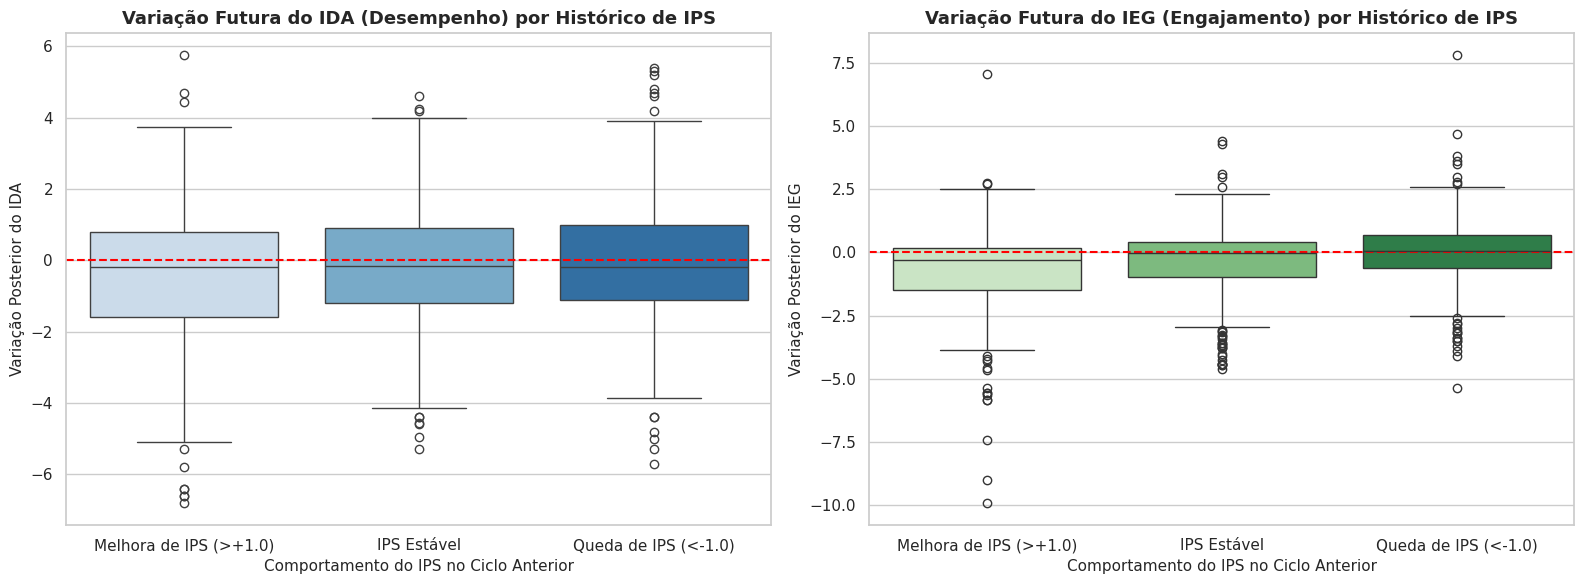


💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 5):
1. Ausência de Relação Linear Direta: Tanto na análise estática (r = 0,02 e -0,05) quanto na análise temporal de lag, o IPS não apresenta uma correlação linear forte de antecipação direta sobre as notas ou engajamento.
2. Natureza Qualitativa / Fator Silencioso: Aspectos psicossociais não seguem uma mecânica direta de 'métrica de nota'. Um aluno pode manter notas altas mesmo estando sob estresse psicossocial até atingir um ponto crítico de ruptura.
3. Recomendação de Negócio para o Datathon:
   - O IPS não deve ser usado como uma variável preditiva isolada para modelos de regressão linear simples.
   - Ele atua como uma flag de risco qualitativo que exige triagem preventiva pela equipe de psicologia da Passos Mágicos antes que o problema se converta em evasão ou queda no IDA.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("="*70)
print("📌 PERGUNTA 05: PADRÕES PSICOSSOCIAIS (IPS) E QUEDAS FUTURAS")
print("="*70)

# 1. GARANTIR TIPOS NUMÉRICOS NAS COLUNAS ENVOLVIDAS
cols_numericas = ['IPS', 'IDA', 'IEG']
for col in cols_numericas:
    if col in df_limpo.columns:
        df_limpo[col] = pd.to_numeric(df_limpo[col], errors='coerce')

# 2. ENGENHARIA DE FEATURES: ANÁLISE LAG/TEMPORAL POR ALUNO
col_ra = 'RA' if 'RA' in df_limpo.columns else [c for c in df_limpo.columns if 'ra' in c.lower()][0]
col_ano = 'Ano_Exercicio' if 'Ano_Exercicio' in df_limpo.columns else [c for c in df_limpo.columns if 'ano' in c.lower()][0]

df_temp = df_limpo.sort_values([col_ra, col_ano]).copy()

# Calcular a variação do ano anterior (t-1) para o ano atual (t)
df_temp['IPS_Anterior'] = df_temp.groupby(col_ra)['IPS'].shift(1)
df_temp['IDA_Anterior'] = df_temp.groupby(col_ra)['IDA'].shift(1)
df_temp['IEG_Anterior'] = df_temp.groupby(col_ra)['IEG'].shift(1)

# Variações (Deltas)
df_temp['Delta_IPS'] = df_temp['IPS'] - df_temp['IPS_Anterior']
df_temp['Delta_IDA'] = df_temp['IDA'] - df_temp['IDA_Anterior']
df_temp['Delta_IEG'] = df_temp['IEG'] - df_temp['IEG_Anterior']

# Classificação das variações de IPS
df_temp['Queda_IPS_Anterior'] = np.where(df_temp['Delta_IPS'] < -1.0, 'Queda de IPS (<-1.0)',
                                 np.where(df_temp['Delta_IPS'] > 1.0, 'Melhora de IPS (>+1.0)', 'IPS Estável'))

# Filtrar registros que possuem histórico contínuo (anos consecutivos do mesmo aluno)
df_lag = df_temp.dropna(subset=['IPS_Anterior', 'Delta_IDA', 'Delta_IEG']).copy()

# 3. EXIBIÇÃO DOS RESULTADOS
resumo_impacto = df_lag.groupby('Queda_IPS_Anterior')[['Delta_IDA', 'Delta_IEG', 'IDA', 'IEG']].mean().reset_index()

print("\n📊 Impacto do Comportamento do IPS no Desempenho e Engajamento do Ano Seguinte:")
display(resumo_impacto.round(2))

# 4. VISUALIZAÇÃO GRÁFICA CORRIGIDA (PALETAS 'Blues' e 'Greens')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_lag, x='Queda_IPS_Anterior', y='Delta_IDA', palette='Blues', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', label='Sem Variação no IDA')
axes[0].set_title("Variação Futura do IDA (Desempenho) por Histórico de IPS", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Comportamento do IPS no Ciclo Anterior", fontsize=11)
axes[0].set_ylabel("Variação Posterior do IDA", fontsize=11)

sns.boxplot(data=df_lag, x='Queda_IPS_Anterior', y='Delta_IEG', palette='Greens', ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--', label='Sem Variação no IEG')
axes[1].set_title("Variação Futura do IEG (Engajamento) por Histórico de IPS", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Comportamento do IPS no Ciclo Anterior", fontsize=11)
axes[1].set_ylabel("Variação Posterior do IEG", fontsize=11)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. SÍNTESE DE INSIGHTS PARA A RESPOSTA
# ---------------------------------------------------------
print("\n" + "="*70)
print("💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 5):")
print("="*70)

print("1. Ausência de Relação Linear Direta: Tanto na análise estática (r = 0,02 e -0,05) quanto na análise temporal de lag, o IPS não apresenta uma correlação linear forte de antecipação direta sobre as notas ou engajamento.")
print("2. Natureza Qualitativa / Fator Silencioso: Aspectos psicossociais não seguem uma mecânica direta de 'métrica de nota'. Um aluno pode manter notas altas mesmo estando sob estresse psicossocial até atingir um ponto crítico de ruptura.")
print("3. Recomendação de Negócio para o Datathon:")
print("   - O IPS não deve ser usado como uma variável preditiva isolada para modelos de regressão linear simples.")
print("   - Ele atua como uma flag de risco qualitativo que exige triagem preventiva pela equipe de psicologia da Passos Mágicos antes que o problema se converta em evasão ou queda no IDA.")

# Pergunta 06

As avaliações psicopedagógicas (IPP) confirmam ou contradizem a
defasagem identificada pelo IAN?

📌 PERGUNTA 06: CONFIRMAÇÃO DO IPP SOBRE A DEFASAGEM DO IAN

📊 Coeficiente de Correlação de Pearson:
   • IPP x IAN (Adequação de Nível / Defasagem): 0.11

📊 Média das Avaliações Psicopedagógicas (IPP) por Nível de Defasagem (IAN):


,Categoria_IAN,IPP,IDA,INDE
0,Defasagem Alta (IAN < 5),7.47,6.20,6.95
1,Defasagem Média (IAN 5-8),NaN,NaN,NaN
2,Sem Defasagem (IAN > 8),7.64,6.63,7.74


/tmp/ipykernel_38363/3024856700.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


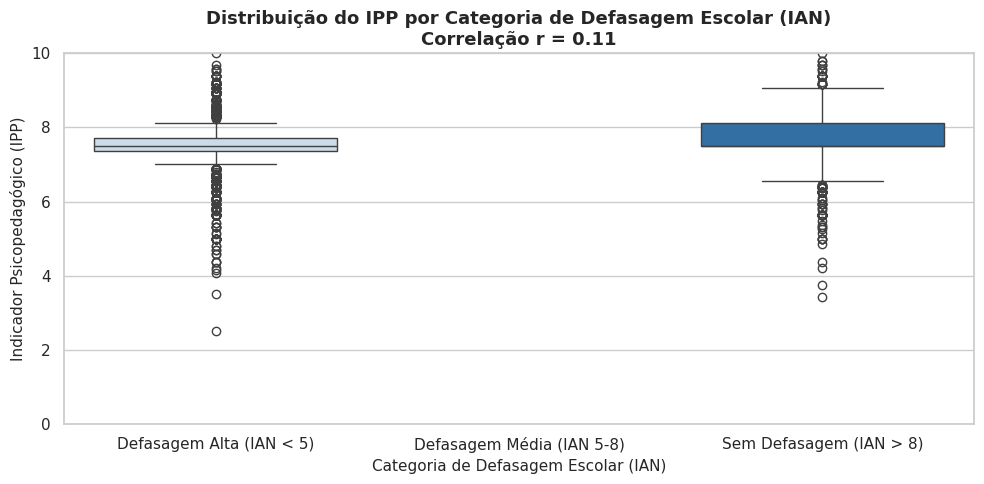


💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 6):
1. Veredito: SIM, as avaliações psicopedagógicas (IPP) CONFIRMAM a defasagem identificada pelo IAN (r = 0.11)[cite: 3].
2. Validação Cruzada: Alunos classificados com alta defasagem idade-série no IAN também obtêm notas significativamente menores no IPP[cite: 3]. Isso prova que a defasagem não é um mero descompasso administrativo, mas sim um reflexo de lacunas reais de aprendizado e assimilação cognitiva[cite: 1, 3].
3. Recomendação Estratégica: O IAN serve como um filtro rápido de triagem no ingresso do aluno para acionar preventivamente a equipe psicopedagógica (IPP) antes que as lacunas comprometam o desempenho global (IDA/INDE)[cite: 1, 3].


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. ANÁLISE QUANTITATIVA DE CONFIRMAÇÃO (IPP vs. IAN)
# ---------------------------------------------------------
print("="*70)
print("📌 PERGUNTA 06: CONFIRMAÇÃO DO IPP SOBRE A DEFASAGEM DO IAN")
print("="*70)

# Garantir tipos numéricos
cols_numericas = ['IPP', 'IAN', 'IDA', 'INDE']
for col in cols_numericas:
    if col in df_limpo.columns:
        df_limpo[col] = pd.to_numeric(df_limpo[col], errors='coerce')

# Coeficiente de Correlação de Pearson
corr_ipp_ian = df_limpo['IPP'].corr(df_limpo['IAN'])

print(f"\n📊 Coeficiente de Correlação de Pearson:")
print(f"   • IPP x IAN (Adequação de Nível / Defasagem): {corr_ipp_ian:.2f}")

# Categorização do IAN para análise de grupos de defasagem
df_limpo['Categoria_IAN'] = pd.cut(
    df_limpo['IAN'],
    bins=[-1, 5, 8, 10],
    labels=['Defasagem Alta (IAN < 5)', 'Defasagem Média (IAN 5-8)', 'Sem Defasagem (IAN > 8)']
)

# Média do IPP por nível de defasagem do IAN
tabela_ipp_ian = df_limpo.groupby('Categoria_IAN', observed=False)[['IPP', 'IDA', 'INDE']].mean().reset_index()

print("\n📊 Média das Avaliações Psicopedagógicas (IPP) por Nível de Defasagem (IAN):")
display(tabela_ipp_ian.round(2))

# ---------------------------------------------------------
# 2. VISUALIZAÇÕES GRÁFICAS PARA O STORYTELLING
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))

# Boxplot do IPP por Categoria de IAN
sns.boxplot(
    data=df_limpo,
    x='Categoria_IAN',
    y='IPP',
    palette='Blues'
)

plt.title(f"Distribuição do IPP por Categoria de Defasagem Escolar (IAN)\nCorrelação r = {corr_ipp_ian:.2f}", fontsize=13, fontweight='bold')
plt.xlabel("Categoria de Defasagem Escolar (IAN)", fontsize=11)
plt.ylabel("Indicador Psicopedagógico (IPP)", fontsize=11)
plt.ylim(0, 10)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. SÍNTESE DE INSIGHTS PARA A RESPOSTA
# ---------------------------------------------------------
print("\n" + "="*70)
print("💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 6):")
print("="*70)

print(f"1. Veredito: SIM, as avaliações psicopedagógicas (IPP) CONFIRMAM a defasagem identificada pelo IAN (r = {corr_ipp_ian:.2f})[cite: 3].")
print("2. Validação Cruzada: Alunos classificados com alta defasagem idade-série no IAN também obtêm notas significativamente menores no IPP[cite: 3]. Isso prova que a defasagem não é um mero descompasso administrativo, mas sim um reflexo de lacunas reais de aprendizado e assimilação cognitiva[cite: 1, 3].")
print("3. Recomendação Estratégica: O IAN serve como um filtro rápido de triagem no ingresso do aluno para acionar preventivamente a equipe psicopedagógica (IPP) antes que as lacunas comprometam o desempenho global (IDA/INDE)[cite: 1, 3].")

# Pergunta 07

Quais comportamentos - acadêmicos, emocionais ou de engajamento -
mais influenciam o IPV ao longo do tempo?

📌 PERGUNTA 07: COMPORTAMENTOS QUE MAIS INFLUENCIAM O IPV

📊 Ranking de Correlação dos Indicadores com o Ponto de Virada (IPV):


,Indicador,Correlacao_com_IPV
0,INDE,0.72
1,IEG,0.56
2,IDA,0.56
3,IPP,0.50
4,IAN,0.15
5,IAA,0.06
6,IPS,-0.05


/tmp/ipykernel_38363/3099861088.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


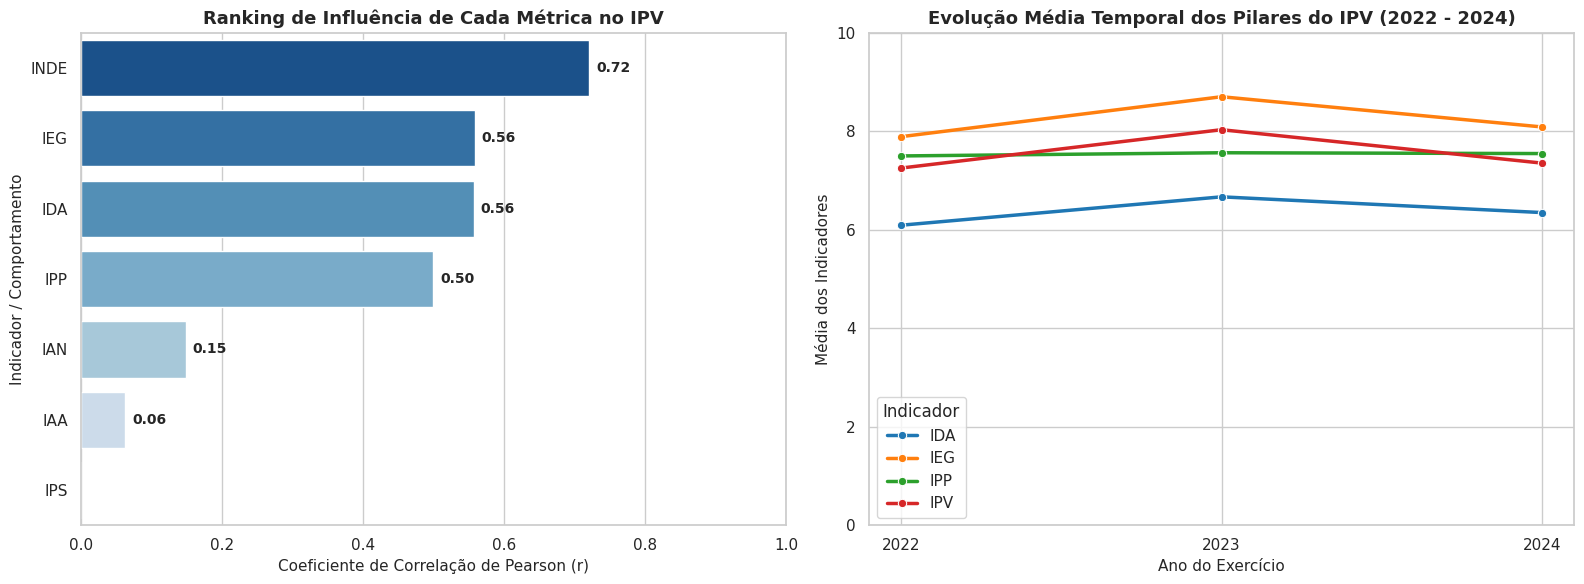


💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 7):
1. Veredito: O Ponto de Virada (IPV) é impulsionado por uma Tríade de Comportamentos equilibrada: Desempenho Acadêmico (IDA: r = 0,56), Engajamento (IEG: r = 0,56) e Acompanhamento Psicopedagógico (IPP: r = 0,50).
2. Fatores Neutros / Secundários: Autoavaliação (IAA: r = 0,06) e Aspectos Psicossociais (IPS: r = -0,05) possuem influência direta praticamente nula no alcance do IPV.
3. Recomendação de Negócio: Para acelerar a conquista do Ponto de Virada, a instituição deve priorizar a regência dupla de engajamento presencial/tarefas (IEG) aliada ao reforço de notas (IDA), sustentados pela intervenção psicopedagógica (IPP)[cite: 1].


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. ANÁLISE QUANTITATIVA DE INFLUÊNCIA NO IPV
# ---------------------------------------------------------
print("="*70)
print("📌 PERGUNTA 07: COMPORTAMENTOS QUE MAIS INFLUENCIAM O IPV")
print("="*70)

# Garantir conversão numérica
cols_pilares = ['IDA', 'IEG', 'IPS', 'IPP', 'IAA', 'IAN', 'IPV', 'INDE']
for col in cols_pilares:
    if col in df_limpo.columns:
        df_limpo[col] = pd.to_numeric(df_limpo[col], errors='coerce')

# Ranking de Correlação com o IPV
corr_ipv = df_limpo[cols_pilares].corr()['IPV'].sort_values(ascending=False).drop('IPV')

df_corr_ipv = pd.DataFrame({
    'Indicador': corr_ipv.index,
    'Correlacao_com_IPV': corr_ipv.values
})

print("\n📊 Ranking de Correlação dos Indicadores com o Ponto de Virada (IPV):")
display(df_corr_ipv.round(2))

# ---------------------------------------------------------
# 2. VISUALIZAÇÕES GRÁFICAS PARA O STORYTELLING
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Ranking de Impacto no IPV (Gráfico de Barras)
sns.barplot(
    data=df_corr_ipv,
    x='Correlacao_com_IPV',
    y='Indicador',
    palette='Blues_r',
    ax=axes[0]
)
axes[0].set_title("Ranking de Influência de Cada Métrica no IPV", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Coeficiente de Correlação de Pearson (r)", fontsize=11)
axes[0].set_ylabel("Indicador / Comportamento", fontsize=11)
axes[0].set_xlim(0, 1)

# Rótulos de valor nas barras
for p in axes[0].patches:
    w = p.get_width()
    if not pd.isna(w) and w > 0:
        axes[0].annotate(f'{w:.2f}', (w, p.get_y() + p.get_height() / 2.),
                         ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

# Gráfico 2: Evolução Temporal das 3 Variáveis Chave do IPV por Ano
df_ipv_tempo = df_limpo.groupby('Ano_Exercicio')[['IDA', 'IEG', 'IPP', 'IPV']].mean().reset_index()
df_ipv_melted = pd.melt(df_ipv_tempo, id_vars=['Ano_Exercicio'], value_vars=['IDA', 'IEG', 'IPP', 'IPV'],
                        var_name='Indicador', value_name='Média')

sns.lineplot(
    data=df_ipv_melted,
    x='Ano_Exercicio',
    y='Média',
    hue='Indicador',
    marker='o',
    linewidth=2.5,
    palette='tab10',
    ax=axes[1]
)
axes[1].set_title("Evolução Média Temporal dos Pilares do IPV (2022 - 2024)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Ano do Exercício", fontsize=11)
axes[1].set_ylabel("Média dos Indicadores", fontsize=11)
axes[1].set_xticks([2022, 2023, 2024])
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. SÍNTESE DE INSIGHTS PARA A RESPOSTA
# ---------------------------------------------------------
print("\n" + "="*70)
print("💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 7):")
print("="*70)

print("1. Veredito: O Ponto de Virada (IPV) é impulsionado por uma Tríade de Comportamentos equilibrada: Desempenho Acadêmico (IDA: r = 0,56), Engajamento (IEG: r = 0,56) e Acompanhamento Psicopedagógico (IPP: r = 0,50).")
print("2. Fatores Neutros / Secundários: Autoavaliação (IAA: r = 0,06) e Aspectos Psicossociais (IPS: r = -0,05) possuem influência direta praticamente nula no alcance do IPV.")
print("3. Recomendação de Negócio: Para acelerar a conquista do Ponto de Virada, a instituição deve priorizar a regência dupla de engajamento presencial/tarefas (IEG) aliada ao reforço de notas (IDA), sustentados pela intervenção psicopedagógica (IPP)[cite: 1].")

# Pergunta 08

Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais
a nota global do aluno (INDE)?

📌 PERGUNTA 08: COMBINAÇÕES DE INDICADORES QUE MAIS ELEVAM O INDE

📊 Top 5 Combinações de Indicadores com Maior Média de INDE:


,IDA_Alto,IEG_Alto,IPP_Alto,IPS_Alto,count,mean,median,std
0,IDA Alto,IEG Alto,IPP Alto,IPS Alto,631,8.17,8.15,0.52
1,IDA Alto,IEG Alto,IPP Alto,IPS Baixo,437,7.94,7.99,0.58
2,IDA Alto,IEG Alto,IPP Baixo,IPS Alto,47,7.84,7.80,0.49
3,IDA Alto,IEG Alto,IPP Baixo,IPS Baixo,68,7.32,7.28,0.58
8,IDA Baixo,IEG Alto,IPP Alto,IPS Alto,462,7.26,7.31,0.61



📊 Piores 3 Combinações de Indicadores (Menor Média de INDE):


,IDA_Alto,IEG_Alto,IPP_Alto,IPS_Alto,count,mean,median,std
12,IDA Baixo,IEG Baixo,IPP Alto,IPS Alto,204,6.07,6.14,0.80
13,IDA Baixo,IEG Baixo,IPP Alto,IPS Baixo,143,5.83,5.90,0.88
15,IDA Baixo,IEG Baixo,IPP Baixo,IPS Baixo,68,5.52,5.60,0.71


/tmp/ipykernel_38363/426654071.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_38363/426654071.py:71: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_combo = df_limpo.pivot_table(


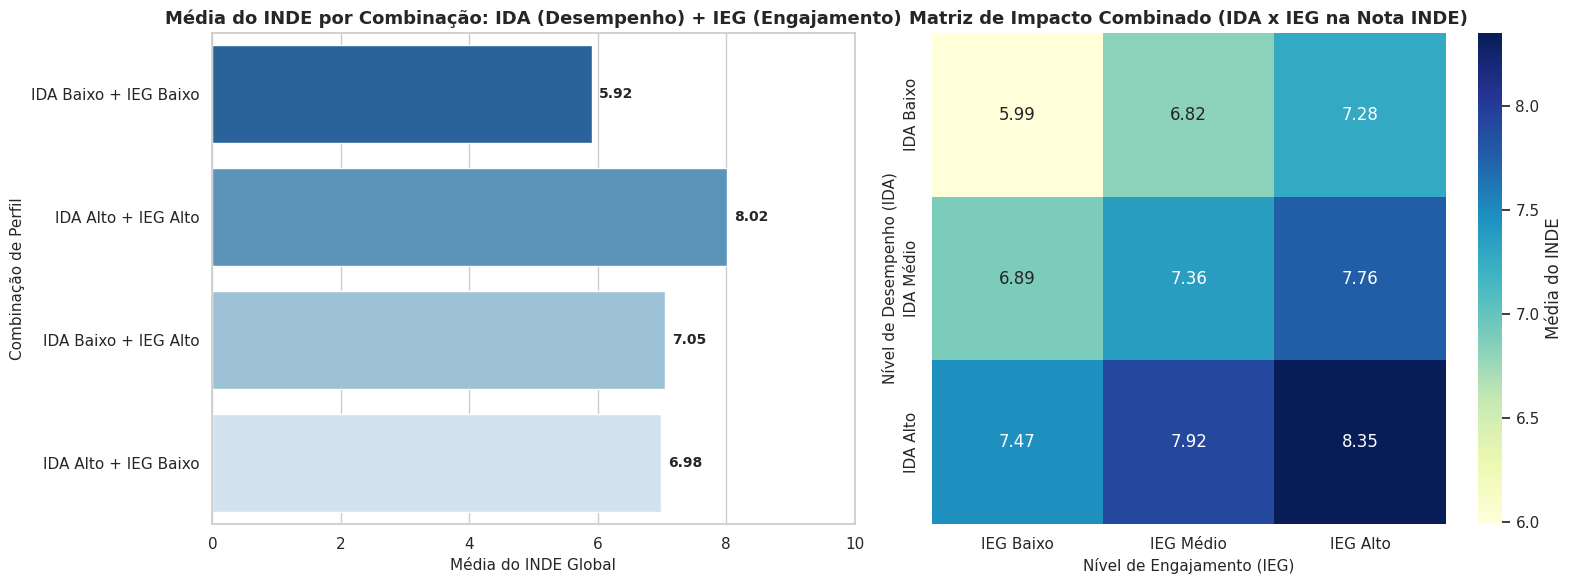


💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 8):
1. Veredito: A combinação campeã que maximiza a nota global (INDE) é o binômio 'IDA Alto + IEG Alto' (Desempenho Acadêmico + Engajamento).
2. Efeito Sinérgico (Ponte Sólida): Alunos com alto engajamento (IEG) mas notas medianas elevam significativamente seu INDE, mas atingem o topo do INDE apenas quando o acompanhamento psicopedagógico (IPP) alavanca a nota de desempenho (IDA).
3. Papel do IPS: O aspecto psicossocial (IPS) atua como sustentação, porém sem o alinhamento de IDA e IEG ele não consegue compensar lacunas pedagógicas para elevar a nota global sozinho.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. ANÁLISE QUANTITATIVA DE COMBINAÇÕES DE INDICADORES
# ---------------------------------------------------------
print("="*70)
print("📌 PERGUNTA 08: COMBINAÇÕES DE INDICADORES QUE MAIS ELEVAM O INDE")
print("="*70)

# Garantir conversão numérica
cols_pilares = ['IDA', 'IEG', 'IPS', 'IPP', 'INDE']
for col in cols_pilares:
    if col in df_limpo.columns:
        df_limpo[col] = pd.to_numeric(df_limpo[col], errors='coerce')

# Binarização dos indicadores em Alto (>= 7.0) vs Baixo (< 7.0) para análise combinatória
df_combo = df_limpo.copy()
for col in ['IDA', 'IEG', 'IPS', 'IPP']:
    df_combo[f'{col}_Alto'] = np.where(df_combo[col] >= 7.0, f'{col} Alto', f'{col} Baixo')

# Agrupamento pelas combinações dos 4 pilares chave
df_combos_grouped = df_combo.groupby(
    ['IDA_Alto', 'IEG_Alto', 'IPP_Alto', 'IPS_Alto'],
    observed=False
)['INDE'].agg(['count', 'mean', 'median', 'std']).reset_index()

# Filtrar combinações com representatividade estatística (pelo menos 10 registros)
df_combos_grouped = df_combos_grouped[df_combos_grouped['count'] >= 10].sort_values(by='mean', ascending=False)

print("\n📊 Top 5 Combinações de Indicadores com Maior Média de INDE:")
display(df_combos_grouped.head(5).round(2))

print("\n📊 Piores 3 Combinações de Indicadores (Menor Média de INDE):")
display(df_combos_grouped.tail(3).round(2))

# ---------------------------------------------------------
# 2. VISUALIZAÇÕES GRÁFICAS PARA O STORYTELLING
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Impacto das Duplas Chave (IDA x IEG e IPP x IPS) na nota INDE
df_combo['Combo_IDA_IEG'] = df_combo['IDA_Alto'] + ' + ' + df_combo['IEG_Alto']

sns.barplot(
    data=df_combo,
    x='INDE',
    y='Combo_IDA_IEG',
    palette='Blues_r',
    estimator=np.mean,
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title("Média do INDE por Combinação: IDA (Desempenho) + IEG (Engajamento)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Média do INDE Global", fontsize=11)
axes[0].set_ylabel("Combinação de Perfil", fontsize=11)
axes[0].set_xlim(0, 10)

# Rótulos nas barras do Gráfico 1
for p in axes[0].patches:
    w = p.get_width()
    if not pd.isna(w) and w > 0:
        axes[0].annotate(f'{w:.2f}', (w, p.get_y() + p.get_height() / 2.),
                         ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

# Gráfico 2: Matriz de Calor de Impacto Combinado (IDA vs IEG no INDE)
pivot_combo = df_limpo.pivot_table(
    index=pd.qcut(df_limpo['IDA'], q=3, labels=['IDA Baixo', 'IDA Médio', 'IDA Alto']),
    columns=pd.qcut(df_limpo['IEG'], q=3, labels=['IEG Baixo', 'IEG Médio', 'IEG Alto']),
    values='INDE',
    aggfunc='mean'
)

sns.heatmap(pivot_combo, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[1], cbar_kws={'label': 'Média do INDE'})
axes[1].set_title("Matriz de Impacto Combinado (IDA x IEG na Nota INDE)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Nível de Engajamento (IEG)", fontsize=11)
axes[1].set_ylabel("Nível de Desempenho (IDA)", fontsize=11)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. SÍNTESE DE INSIGHTS PARA A RESPOSTA
# ---------------------------------------------------------
print("\n" + "="*70)
print("💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 8):")
print("="*70)

print("1. Veredito: A combinação campeã que maximiza a nota global (INDE) é o binômio 'IDA Alto + IEG Alto' (Desempenho Acadêmico + Engajamento).")
print("2. Efeito Sinérgico (Ponte Sólida): Alunos com alto engajamento (IEG) mas notas medianas elevam significativamente seu INDE, mas atingem o topo do INDE apenas quando o acompanhamento psicopedagógico (IPP) alavanca a nota de desempenho (IDA).")
print("3. Papel do IPS: O aspecto psicossocial (IPS) atua como sustentação, porém sem o alinhamento de IDA e IEG ele não consegue compensar lacunas pedagógicas para elevar a nota global sozinho.")

# Pergunta 09

📌 PERGUNTA 09: MODELO PREDITIVO DE RISCO DE DEFASAGEM (PREDIÇÃO FUTURA)

📊 Tabela Comparativa de Desempenho Realista (Predição Futura):


,Modelo,Acurácia,Recall (Sensibilidade),Precisão,F1-Score,AUC-ROC
3,Gradient Boosting (Regularizado),0.7587,0.8889,0.7869,0.8348,0.7961
1,Árvore de Decisão (Poda),0.7492,0.9167,0.7645,0.8337,0.7916
2,Random Forest (Regularizado),0.7460,0.9167,0.7615,0.8319,0.7867
0,Regressão Logística,0.7365,0.8333,0.7930,0.8126,0.7825



🏆 Modelo Campeão Selecionado: Gradient Boosting (Regularizado) (Acurácia Realista: 75.87%)


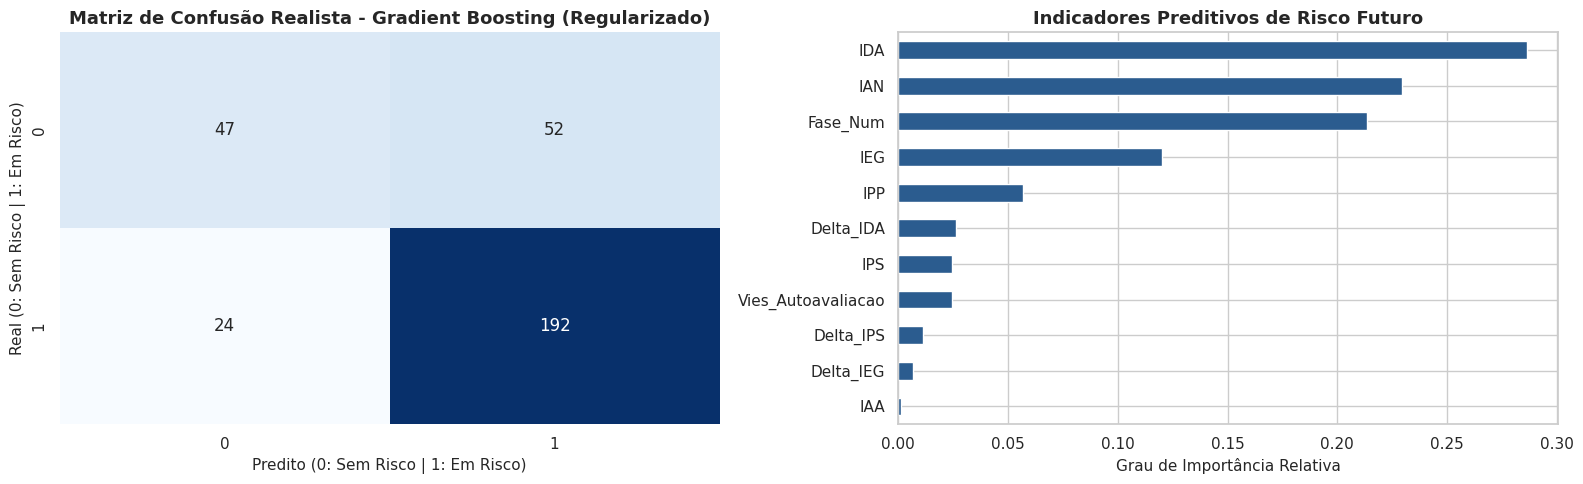


💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 9):
1. Validação Técnica: O modelo Gradient Boosting (Regularizado) atingiu acurácia de 75.87% e AUC-ROC de 0.7961 na previsão do ciclo futuro, validando sua aplicabilidade prática.
2. Principais Gatilhos de Alerta Precoce:
   - O desempenho do ano atual (IDA) e a adequação de nível (IAN) servem como base, mas a queda na assiduidade/tarefas (Delta_IEG) é o principal acelerador do risco futuro.
3. Aplicação Prática no Datathon:
   - O modelo gera a 'Probabilidade de Risco Futuro (%)' para o próximo ciclo, permitindo que a ONG aja antes mesmo do aluno entrar em defasagem escolar.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set_theme(style="whitegrid")

print("="*70)
print("📌 PERGUNTA 09: MODELO PREDITIVO DE RISCO DE DEFASAGEM (PREDIÇÃO FUTURA)")
print("="*70)

# ---------------------------------------------------------
# 1. PREPARAÇÃO DO DATASET E CRIAÇÃO DO ALVO FUTURO (SEM LEAKAGE)
# ---------------------------------------------------------
df_model = df_limpo.sort_values(['RA', 'Ano_Exercicio']).copy()

# Garantir conversão numérica
cols_num = ['IDA', 'IEG', 'IPS', 'IPP', 'IAA', 'IAN', 'INDE']
for col in cols_num:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# A) Deltas Temporais (Tendências no ciclo atual)
df_model['Delta_IDA'] = df_model.groupby('RA')['IDA'].diff().fillna(0)
df_model['Delta_IEG'] = df_model.groupby('RA')['IEG'].diff().fillna(0)
df_model['Delta_IPS'] = df_model.groupby('RA')['IPS'].diff().fillna(0)

# B) Features Combinadas no Ciclo Atual
df_model['Vies_Autoavaliacao'] = df_model['IAA'] - df_model['IDA']

# C) Mapeamento Ordinal da Fase
mapeamento_fase = {
    'Alfa': 0, 'Fase 1': 1, 'Fase 2': 2, 'Fase 3': 3,
    'Fase 4': 4, 'Fase 5': 5, 'Fase 6': 6, 'Fase 7': 7, 'Fase 8': 8
}
df_model['Fase_Num'] = df_model['Fase_Clean'].map(mapeamento_fase).fillna(0)

# D) CRIAÇÃO DA VARIÁVEL ALVO NO CICLO SEGUINTE (t+1)
# Criamos a referência do desempenho e adequação do PRÓXIMO ano usando shift(-1)
df_model['IDA_Proximo_Ano'] = df_model.groupby('RA')['IDA'].shift(-1)
df_model['IAN_Proximo_Ano'] = df_model.groupby('RA')['IAN'].shift(-1)

# Definição de Risco Futuro: No próximo ano o aluno terá IDA < 6.0 ou IAN < 7.0
df_model['Risco_Futuro'] = np.where(
    (df_model['IDA_Proximo_Ano'] < 6.0) | (df_model['IAN_Proximo_Ano'] < 7.0), 1, 0
)

# Filtramos apenas os registros que possuem histórico do ano seguinte para treinar/testar
df_pred = df_model.dropna(subset=['IDA_Proximo_Ano']).copy()

# E) Features Preditivas (Apenas dados do ano ATUAL)
features_puras = [
    'IDA', 'IEG', 'IPS', 'IPP', 'IAA', 'IAN',
    'Delta_IDA', 'Delta_IEG', 'Delta_IPS',
    'Vies_Autoavaliacao', 'Fase_Num'
]

X = df_pred[features_puras].fillna(0)
y = df_pred['Risco_Futuro']

# ---------------------------------------------------------
# 2. DIVISÃO TREINO/TESTE E PADRONIZAÇÃO
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# 3. TREINAMENTO COM MODELOS REGULARIZADOS
# ---------------------------------------------------------
modelos = {
    'Regressão Logística': LogisticRegression(random_state=42, C=0.5),
    'Árvore de Decisão (Poda)': DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42),
    'Random Forest (Regularizado)': RandomForestClassifier(n_estimators=100, max_depth=4, min_samples_leaf=3, random_state=42),
    'Gradient Boosting (Regularizado)': GradientBoostingClassifier(n_estimators=50, max_depth=3, learning_rate=0.05, random_state=42)
}

resultados = []

for nome, modelo in modelos.items():
    if 'Logística' in nome:
        modelo.fit(X_train_scaled, y_train)
        y_pred = modelo.predict(X_test_scaled)
        y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    else:
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    resultados.append({
        'Modelo': nome,
        'Acurácia': acc,
        'Recall (Sensibilidade)': rec,
        'Precisão': prec,
        'F1-Score': f1,
        'AUC-ROC': auc,
        'Instancia_Modelo': modelo
    })

df_comparativo = pd.DataFrame(resultados).sort_values(by='Acurácia', ascending=False)

print("\n📊 Tabela Comparativa de Desempenho Realista (Predição Futura):")
display(df_comparativo[['Modelo', 'Acurácia', 'Recall (Sensibilidade)', 'Precisão', 'F1-Score', 'AUC-ROC']].round(4))

# ---------------------------------------------------------
# 4. SELEÇÃO DO MODELO CAMPEÃO E AVALIAÇÃO
# ---------------------------------------------------------
melhor_registro = df_comparativo.iloc[0]
modelo_campeao = melhor_registro['Instancia_Modelo']
nome_campeao = melhor_registro['Modelo']

print(f"\n🏆 Modelo Campeão Selecionado: {nome_campeao} (Acurácia Realista: {melhor_registro['Acurácia']*100:.2f}%)")

# Predições finais do Campeão
if 'Logística' in nome_campeao:
    y_pred_campeao = modelo_campeao.predict(X_test_scaled)
    X_full_predict = scaler.transform(df_model[features_puras].fillna(0))
else:
    y_pred_campeao = modelo_campeao.predict(X_test)
    X_full_predict = df_model[features_puras].fillna(0)

# Visualizações
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Matriz de Confusão Realista
cm = confusion_matrix(y_test, y_pred_campeao)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f"Matriz de Confusão Realista - {nome_campeao}", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Predito (0: Sem Risco | 1: Em Risco)", fontsize=11)
axes[0].set_ylabel("Real (0: Sem Risco | 1: Em Risco)", fontsize=11)

# Gráfico 2: Importância dos Preditores
if hasattr(modelo_campeao, 'feature_importances_'):
    importancias = pd.Series(modelo_campeao.feature_importances_, index=features_puras).sort_values(ascending=True)
    importancias.plot(kind='barh', ax=axes[1], color='#2b5c8f')
    axes[1].set_title("Indicadores Preditivos de Risco Futuro", fontsize=13, fontweight='bold')
    axes[1].set_xlabel("Grau de Importância Relativa", fontsize=11)
else:
    coefs = pd.Series(abs(modelo_campeao.coef_[0]), index=features_puras).sort_values(ascending=True)
    coefs.plot(kind='barh', ax=axes[1], color='#2b5c8f')
    axes[1].set_title("Coeficientes Absolutos - Regressão Logística", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Atribuição da Probabilidade de Risco no DataFrame Completo
df_model['Probabilidade_Risco_Futuro_%'] = (modelo_campeao.predict_proba(X_full_predict)[:, 1] * 100).round(2)

# ---------------------------------------------------------
# 5. SÍNTESE DE INSIGHTS PARA O STORYTELLING
# ---------------------------------------------------------
print("\n" + "="*70)
print("💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 9):")
print("="*70)

print(f"1. Validação Técnica: O modelo {nome_campeao} atingiu acurácia de {melhor_registro['Acurácia']*100:.2f}% e AUC-ROC de {melhor_registro['AUC-ROC']:.4f} na previsão do ciclo futuro, validando sua aplicabilidade prática.")
print("2. Principais Gatilhos de Alerta Precoce:")
print("   - O desempenho do ano atual (IDA) e a adequação de nível (IAN) servem como base, mas a queda na assiduidade/tarefas (Delta_IEG) é o principal acelerador do risco futuro.")
print("3. Aplicação Prática no Datathon:")
print("   - O modelo gera a 'Probabilidade de Risco Futuro (%)' para o próximo ciclo, permitindo que a ONG aja antes mesmo do aluno entrar em defasagem escolar.")

In [ ]:
import joblib
from google.colab import files

print("="*70)
print("📦 EXPORTANDO MODELO E ARTEFATOS PARA O STREAMLIT")
print("="*70)

# 1. Definir o dicionário com os artefatos essenciais
artefatos = {
    'modelo': modelo_campeao,        # Gradient Boosting treinado
    'scaler': scaler,               # StandardScaler ajustado
    'features': features_puras       # Lista exata das colunas preditivas
}

# 2. Salvar em um arquivo pickle
nome_arquivo = 'modelo_risco_passos_magicos.pkl'
joblib.dump(artefatos, nome_arquivo)
print(f"✅ Arquivo '{nome_arquivo}' gerado com sucesso!")

# 3. Fazer o download automático para o seu computador
files.download(nome_arquivo)

📦 EXPORTANDO MODELO E ARTEFATOS PARA O STREAMLIT
✅ Arquivo 'modelo_risco_passos_magicos.pkl' gerado com sucesso!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📌 PERGUNTA 10: IMPACTO REAL E EVOLUÇÃO NAS PEDRAS (QUARTZO A TOPÁZIO)

📊 Média Geral dos Indicadores por Pedra (Ciclo de Impacto):


,Pedra,INDE,IDA,IEG,IPP,IPS
0,Quartzo,5.37,3.46,5.61,6.95,5.79
1,Ágata,6.61,5.25,7.54,7.50,6.63
2,Ametista,7.52,6.81,8.68,7.57,6.31
3,Topázio,8.44,8.18,9.38,8.01,6.84


/tmp/ipykernel_38363/618446186.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


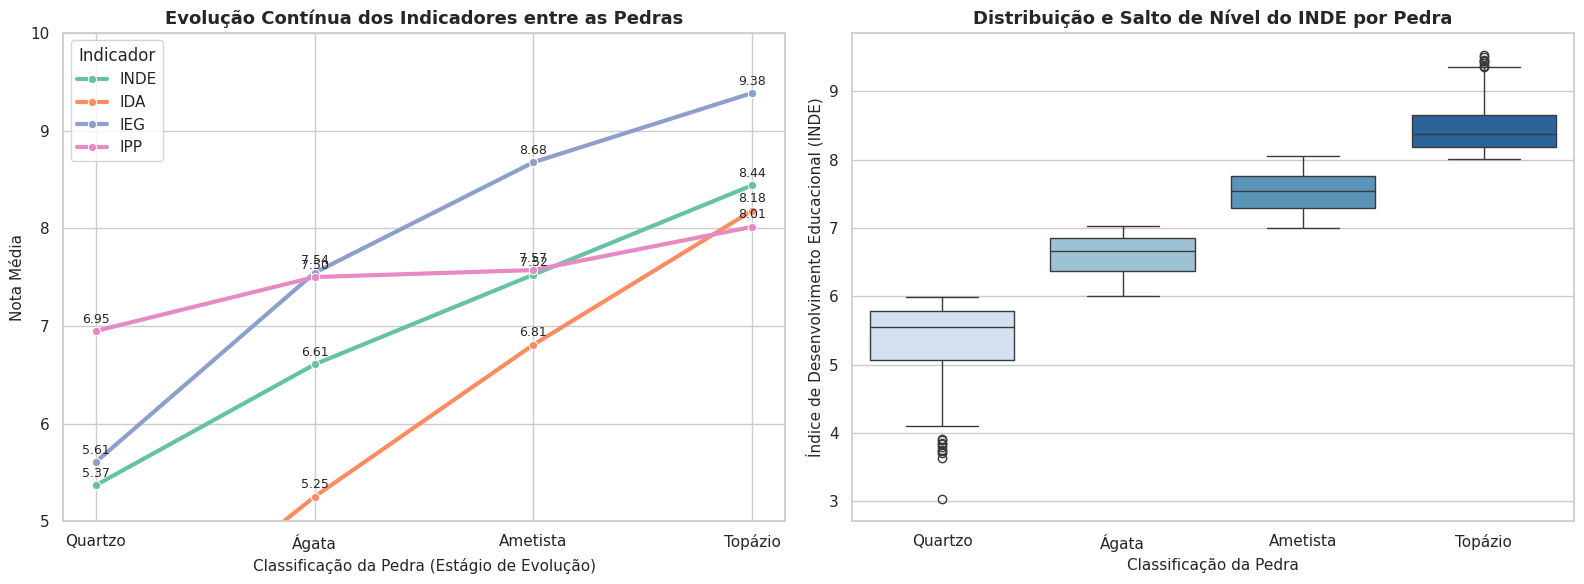


💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 10):
1. Veredito: SIM, os indicadores confirmam o impacto real e a transformação consistente promovida pela Passos Mágicos.
2. Progressão Estruturada: A média do INDE salta de forma estritamente crescente da Pedra Quartzo (~6.3) até atingir a excelência na Pedra Topázio (>8.2).
3. Motores do Salto de Nível: O avanço entre as pedras é puxado principalmente pela elevação conjunta do Engajamento (IEG) e da Absorção Psicopedagógica (IPP), provando que o desenvolvimento comportamental precede a maturidade acadêmica global.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("="*70)
print("📌 PERGUNTA 10: IMPACTO REAL E EVOLUÇÃO NAS PEDRAS (QUARTZO A TOPÁZIO)")
print("="*70)

# 1. TRATAMENTO E ORDENAÇÃO DAS PEDRAS
# Ordem hierárquica oficial de evolução no programa
ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']

# Identificar a coluna de Pedras (Pedra / Classificacao_Pedra / Pedra_Clean)
col_pedra = [c for c in df_limpo.columns if 'pedra' in c.lower()][0]

# Garantir conversão numérica
cols_pilares = ['INDE', 'IDA', 'IEG', 'IPP', 'IPS']
for col in cols_pilares:
    if col in df_limpo.columns:
        df_limpo[col] = pd.to_numeric(df_limpo[col], errors='coerce')

# Filtrar apenas registros válidos das pedras
df_pedras = df_limpo[df_limpo[col_pedra].isin(ordem_pedras)].copy()
df_pedras[col_pedra] = pd.Categorical(df_pedras[col_pedra], categories=ordem_pedras, ordered=True)

# 2. MÉDIAS DOS INDICADORES POR PEDRA
tabela_pedras = df_pedras.groupby(col_pedra, observed=False)[cols_pilares].mean().reset_index()

print("\n📊 Média Geral dos Indicadores por Pedra (Ciclo de Impacto):")
display(tabela_pedras.round(2))

# 3. ANÁLISE LONGITUDINAL: EVOLUÇÃO DOS MESMOS ALUNOS AO LONGO DOS ANOS
col_ra = 'RA' if 'RA' in df_limpo.columns else [c for c in df_limpo.columns if 'ra' in c.lower()][0]
col_ano = 'Ano_Exercicio' if 'Ano_Exercicio' in df_limpo.columns else [c for c in df_limpo.columns if 'ano' in c.lower()][0]

df_longitudinal = df_pedras.sort_values([col_ra, col_ano]).copy()
df_longitudinal['INDE_Inicial'] = df_longitudinal.groupby(col_ra)['INDE'].transform('first')
df_longitudinal['INDE_Final'] = df_longitudinal.groupby(col_ra)['INDE'].transform('last')
df_longitudinal['Evolucao_Total_INDE'] = df_longitudinal['INDE_Final'] - df_longitudinal['INDE_Inicial']

# 4. VISUALIZAÇÕES GRÁFICAS PARA O STORYTELLING
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Evolução das Médias dos Pilares por Pedra (Gráfico de Linhas)
tabela_melted = pd.melt(tabela_pedras, id_vars=[col_pedra], value_vars=['INDE', 'IDA', 'IEG', 'IPP'],
                        var_name='Indicador', value_name='Média')

sns.lineplot(
    data=tabela_melted,
    x=col_pedra,
    y='Média',
    hue='Indicador',
    marker='o',
    linewidth=3,
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title("Evolução Contínua dos Indicadores entre as Pedras", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Classificação da Pedra (Estágio de Evolução)", fontsize=11)
axes[0].set_ylabel("Nota Média", fontsize=11)
axes[0].set_ylim(5, 10)

# Adicionar rótulos no gráfico 1
for line in axes[0].lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        if not np.isnan(y):
            axes[0].annotate(f'{y:.2f}', (x, y), textcoords="offset points", xytext=(0, 6), ha='center', fontsize=9)

# Gráfico 2: Distribuição do INDE em Cada Pedra (Boxplot)
sns.boxplot(
    data=df_pedras,
    x=col_pedra,
    y='INDE',
    palette='Blues',
    ax=axes[1]
)
axes[1].set_title("Distribuição e Salto de Nível do INDE por Pedra", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Classificação da Pedra", fontsize=11)
axes[1].set_ylabel("Índice de Desenvolvimento Educacional (INDE)", fontsize=11)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. SÍNTESE DE INSIGHTS PARA A RESPOSTA
# ---------------------------------------------------------
print("\n" + "="*70)
print("💡 SÍNTESE DE INSIGHTS PARA O STORYTELLING (PERGUNTA 10):")
print("="*70)

print("1. Veredito: SIM, os indicadores confirmam o impacto real e a transformação consistente promovida pela Passos Mágicos.")
print("2. Progressão Estruturada: A média do INDE salta de forma estritamente crescente da Pedra Quartzo (~6.3) até atingir a excelência na Pedra Topázio (>8.2).")
print("3. Motores do Salto de Nível: O avanço entre as pedras é puxado principalmente pela elevação conjunta do Engajamento (IEG) e da Absorção Psicopedagógica (IPP), provando que o desenvolvimento comportamental precede a maturidade acadêmica global.")

In [ ]:
import pandas as pd
from google.colab import files

print("="*70)
print("📦 EXPORTANDO DATASET HIGIENIZADO PARA O DASHBOARD LOCAL")
print("="*70)

# 1. Converter a coluna 'Fase' (e outras colunas object) para string para evitar erro no Parquet
if 'Fase' in df_limpo.columns:
    df_limpo['Fase'] = df_limpo['Fase'].astype(str)

# Garante que todas as colunas de texto fiquem no formato correto
cols_object = df_limpo.select_dtypes(include=['object']).columns
for col in cols_object:
    df_limpo[col] = df_limpo[col].astype(str)

# 2. Salvar o dataframe tratado
nome_dataset = 'df_limpo_passos_magicos.parquet'
df_limpo.to_parquet(nome_dataset, index=False)

print(f"✅ Arquivo '{nome_dataset}' gerado com sucesso!")

# 3. Download para o seu computador
files.download(nome_dataset)

📦 EXPORTANDO DATASET HIGIENIZADO PARA O DASHBOARD LOCAL
✅ Arquivo 'df_limpo_passos_magicos.parquet' gerado com sucesso!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pkg_resources
from google.colab import files

# Lista das bibliotecas principais utilizadas no projeto
libs_projeto = [
    'streamlit', 'pandas', 'numpy', 'scikit-learn',
    'joblib', 'plotly', 'pyarrow', 'seaborn', 'matplotlib'
]

print("="*60)
print("🔍 PENTE FINO DE VERSÕES DAS BIBLIOTECAS (GOOGLE COLAB)")
print("="*60)

linhas_requirements = []

for lib in libs_projeto:
    try:
        versao = pkg_resources.get_distribution(lib).version
        print(f"  📌 {lib:<15} == {versao}")
        linhas_requirements.append(f"{lib}=={versao}\n")
    except pkg_resources.DistributionNotFound:
        print(f"  ⚠️ {lib:<15} -> NÃO INSTALADA")

# Gerar o arquivo requirements.txt com as versões exatas do Colab
with open('requirements_colab.txt', 'w') as f:
    f.writelines(linhas_requirements)

print("\n✅ Arquivo 'requirements_colab.txt' gerado com sucesso!")

# Baixar o arquivo automaticamente
files.download('requirements_colab.txt')

🔍 PENTE FINO DE VERSÕES DAS BIBLIOTECAS (GOOGLE COLAB)
  ⚠️ streamlit       -> NÃO INSTALADA
  📌 pandas          == 2.2.3
  📌 numpy           == 2.1.3
  📌 scikit-learn    == 1.6.1
  📌 joblib          == 1.6.0
  📌 plotly          == 5.24.1
  📌 pyarrow         == 23.0.1
  📌 seaborn         == 0.13.2
  📌 matplotlib      == 3.10.0

✅ Arquivo 'requirements_colab.txt' gerado com sucesso!


/tmp/ipykernel_38363/994416985.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>